# PH3205 Computational Physics — Complete Exam Code Bank
### Papers covered (in order):
1. **Aranya Endsem** (`PH3205-endsem-QA.pdf`) — Rising Bubble, Lennard-Jones QM, Random Walk, Helium Bohr-Sommerfeld
2. **EndSem_Q** (`EndSem_Q.pdf`) — Newton-Raphson, Nonlinear Oscillator, Shooting BVP, Random Walk, Metropolis
3. **Our CT1** (`our_ct1.pdf`) — Rocket with Drag, Stokes' Law, Damped Gaussian Oscillator, Quantum Elliptic Well
4. **CT2** (`ct2-v4.pdf`) — Cubic Anharmonic Oscillator, Flat-Bottom Well, Half-Harmonic Trap, Finite Parabolic WKB
5. **Class Test 1** (`classtest-1.pdf`) — Planck Integral, LJ Root Finding, Planetary Orbit Verlet, Projectile Drag


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['figure.figsize'] = (9, 5)
rcParams['font.size'] = 12


---
## Shared Utility Functions
These are reused across all problems. Define once, use everywhere.


In [2]:
# ── Standard RK4 (state vector, no parameter) ──────────────────────────────
def rk4(f, x, y, h):
    """Single RK4 step. f(x, y) returns dy/dx as array."""
    k1 = h * f(x, y)
    k2 = h * f(x + h/2, y + k1/2)
    k3 = h * f(x + h/2, y + k2/2)
    k4 = h * f(x + h,   y + k3)
    return y + (k1 + 2*k2 + 2*k3 + k4) / 6

def caller_rk4(f, y_ini, xs, h):
    """Integrate f over array xs with step h. Returns (N, len(y_ini)) array."""
    N = len(xs)
    ys = np.zeros((N, len(y_ini)))
    y = np.array(y_ini, dtype=float)
    for i in range(N):
        ys[i] = y
        y = rk4(f, xs[i], y, h)
    return ys

# ── RK4 with extra parameter k (used in shooting) ─────────────────────────
def rk4_k(f, x, y, k, h):
    """Single RK4 step. f(x, y, k) — k is a parameter (energy, etc)."""
    k1 = h * f(x, y, k)
    k2 = h * f(x + h/2, y + k1/2, k)
    k3 = h * f(x + h/2, y + k2/2, k)
    k4 = h * f(x + h,   y + k3,   k)
    return y + (k1 + 2*k2 + 2*k3 + k4) / 6

def caller_rk4_k(f, xlim, yini, k, N):
    """Integrate f from xlim[0] to xlim[1] with parameter k."""
    xs = np.linspace(xlim[0], xlim[1], N)
    h = xs[1] - xs[0]
    y = np.array(yini, dtype=float)
    ys = np.zeros((N, len(yini)))
    for i in range(N):
        ys[i] = y
        y = rk4_k(f, xs[i], y, k, h)
    return xs, ys

# ── Bisection ──────────────────────────────────────────────────────────────
def bisection(f, L, R, eps=1e-6, maxiter=200):
    """Find root of f in [L,R] by bisection. Returns (root, iterations)."""
    if f(L) * f(R) > 0:
        raise ValueError(f"Bad interval: f(L)={f(L):.4g}, f(R)={f(R):.4g}")
    c = (L + R) / 2
    for it in range(maxiter):
        if abs(f(c)) < eps:
            return c, it
        if f(L) * f(c) <= 0:
            R = c
        else:
            L = c
        c = (L + R) / 2
    print("Bisection: max iterations reached")
    return c, maxiter

# ── Newton-Raphson ─────────────────────────────────────────────────────────
def newton(f, fp, x0, eps=1e-8, maxiter=100):
    """Newton-Raphson root finder. Returns (root, iterations)."""
    x = x0
    for it in range(maxiter):
        fx = f(x)
        if abs(fx) < eps:
            return x, it
        dfx = fp(x)
        if abs(dfx) < eps:
            print("Newton: derivative too small, stopping.")
            return x, it
        print(f"  iter {it+1:3d}  x={x:.8f}  f(x)={fx:.4e}")
        x = x - fx / dfx
    print("Newton: max iterations reached")
    return x, maxiter

# ── Secant method ──────────────────────────────────────────────────────────
def secant(f, x1, x2, eps=1e-8, maxiter=100):
    """Secant method root finder. Returns (root, iterations)."""
    for it in range(maxiter):
        f1, f2 = f(x1), f(x2)
        if abs(f2) < eps:
            return x2, it
        x1, x2 = x2, x2 - f2*(x2-x1)/(f2-f1)
    print("Secant: max iterations reached")
    return x2, maxiter

# ── Numerical integration ──────────────────────────────────────────────────
def simpson(f, a, b, N):
    """Simpson's 1/3 rule. N must be odd (even number of subintervals)."""
    if N % 2 == 0: N += 1
    x = np.linspace(a, b, N)
    h = x[1] - x[0]
    fx = f(x)
    return h/3 * (fx[0] + 4*np.sum(fx[1::2]) + 2*np.sum(fx[2:-1:2]) + fx[-1])

def trapezoid(f_arr, h):
    """Trapezoidal rule on pre-computed array."""
    return h * (0.5*f_arr[0] + np.sum(f_arr[1:-1]) + 0.5*f_arr[-1])

print("Utility functions loaded: rk4, caller_rk4, rk4_k, caller_rk4_k, bisection, newton, secant, simpson, trapezoid")


Utility functions loaded: rk4, caller_rk4, rk4_k, caller_rk4_k, bisection, newton, secant, simpson, trapezoid


---
# 📄 Paper 1: Aranya Endsem (`PH3205-endsem-QA.pdf`)
---


## Q1 — Rising Gas Bubble [30 marks]

### (a) Modelling — Derivations

**Radius as a function of height:**  
At the surface, pressure is $P_0 = P_a + \rho_\ell g H$.  
At height $y$: $P(y) = P_a + \rho_\ell g(H-y)$.  
Ideal gas at constant T: $P(y)V(y) = P_0 V_0 \Rightarrow \frac{4}{3}\pi R^3(y) = \frac{4}{3}\pi R_0^3 \frac{P_0}{P(y)}$

$$\boxed{R(y) = R_0 \left(\frac{P_0}{P(y)}\right)^{1/3}}$$

**Gas density:**  
By ideal gas, $\rho_g(y) V(y) = \rho_{g0} V_0 \Rightarrow \rho_g = \rho_{g0}\frac{V_0}{V(y)} = \rho_{g0}\frac{P(y)}{P_0}$

**Equation of motion:**  
Buoyancy $= \rho_\ell g V(y)$, weight $= \rho_g(y)gV(y)$, Stokes drag $= 6\pi\mu R(y)\dot y$.

$$m_{\rm eff}(y)\,\ddot y = (\rho_\ell - \rho_g(y))\,g\,V(y) - 6\pi\mu R(y)\,\dot y$$

where $m_{\rm eff} = m_g + \tfrac{1}{2}\rho_\ell V(y)$.

**First-order system:** Let $v = \dot y$:
$$\dot y = v, \qquad \dot v = \frac{(\rho_\ell - \rho_g)gV - 6\pi\mu R v}{m_{\rm eff}}$$

### (b) Dimensionless groups
Using scale $R_0$ for length and $t_0 = \sqrt{R_0/g}$ for time:
- Stokes number: $\mathrm{St} = 6\pi\mu/(\rho_\ell\sqrt{g R_0^3})$
- Density ratio: $\delta = \rho_{g0}/\rho_\ell$
- Pressure ratio: $\Pi_0 = P_0/(\rho_\ell g H)$


Total rise time t_surf = 0.5615 s
Max ascent speed       = 2.2635 m/s
Radius at surface      = 1.0313 mm
Volume at surface      = 4.5945 mm³


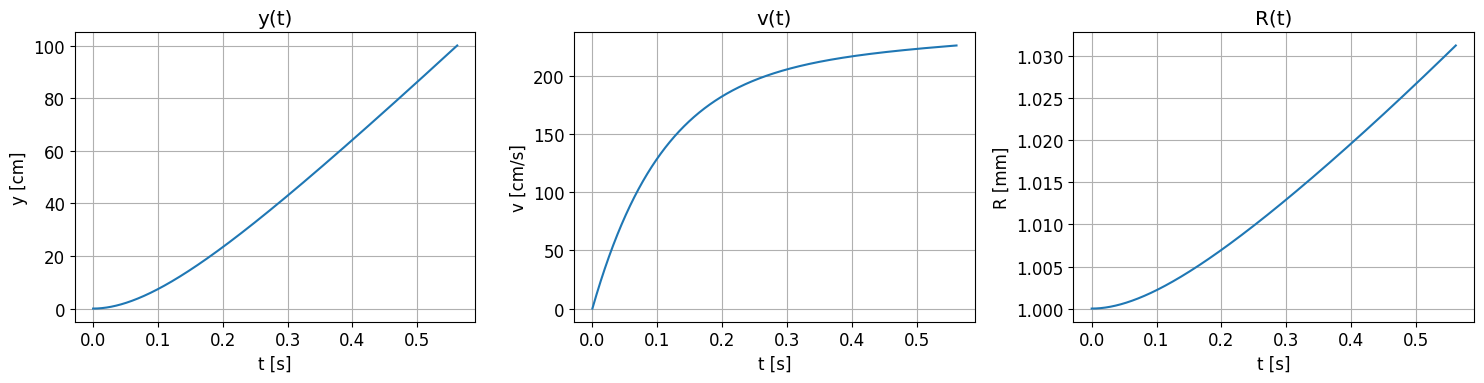

In [3]:
# ── Q1: Rising Gas Bubble ─────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

# Parameters
R0    = 1.0e-3        # initial radius [m]
H     = 1.0           # column height [m]
rho_l = 1.0e3         # water density [kg/m3]
mu    = 1.0e-3        # dynamic viscosity [Pa·s]
Pa    = 1.013e5       # atmospheric pressure [Pa]
T_K   = 293.0         # temperature [K]
g     = 9.81          # gravity [m/s2]
R_gas = 8.314         # gas constant [J/(mol·K)]
M_air = 0.029         # molar mass of air [kg/mol]

P0    = Pa + rho_l * g * H          # pressure at bottom
rho_g0 = P0 * M_air / (R_gas * T_K) # initial gas density

def P(y):
    return Pa + rho_l * g * (H - y)

def R_bubble(y):
    return R0 * (P0 / P(y))**(1/3)

def V_bubble(y):
    R = R_bubble(y)
    return (4/3) * np.pi * R**3

def rho_g(y):
    return rho_g0 * P(y) / P0

def m_eff(y):
    mg  = rho_g(y) * V_bubble(y)
    return mg + 0.5 * rho_l * V_bubble(y)

def odes(t, state):
    y, v = state
    if y >= H:
        return np.array([0.0, 0.0])
    R  = R_bubble(y)
    V  = V_bubble(y)
    rg = rho_g(y)
    me = m_eff(y)
    buoy  = (rho_l - rg) * g * V
    drag  = 6 * np.pi * mu * R * v
    dvdt  = (buoy - drag) / me
    return np.array([v, dvdt])

# Integrate with RK4
h    = 1.0e-4
t    = 0.0
y0   = 0.0
v0   = 0.0
state = np.array([y0, v0])

ts_list, ys_list, vs_list, Rs_list = [t], [y0], [v0], [R0]

while state[0] < H:
    state = rk4(odes, t, state, h)
    t += h
    ts_list.append(t)
    ys_list.append(state[0])
    vs_list.append(state[1])
    Rs_list.append(R_bubble(state[0]))

ts = np.array(ts_list)
ys = np.array(ys_list)
vs = np.array(vs_list)
Rs = np.array(Rs_list)

# Results
t_surf = ts[-1]
v_max  = np.max(vs)
R_surf = Rs[-1]
V_surf = (4/3)*np.pi*R_surf**3

print(f"Total rise time t_surf = {t_surf:.4f} s")
print(f"Max ascent speed       = {v_max:.4f} m/s")
print(f"Radius at surface      = {R_surf*1e3:.4f} mm")
print(f"Volume at surface      = {V_surf*1e9:.4f} mm³")

# Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(ts, ys*100); axes[0].set_xlabel('t [s]'); axes[0].set_ylabel('y [cm]'); axes[0].set_title('y(t)'); axes[0].grid()
axes[1].plot(ts, vs*100); axes[1].set_xlabel('t [s]'); axes[1].set_ylabel('v [cm/s]'); axes[1].set_title('v(t)'); axes[1].grid()
axes[2].plot(ts, Rs*1e3); axes[2].set_xlabel('t [s]'); axes[2].set_ylabel('R [mm]'); axes[2].set_title('R(t)'); axes[2].grid()
plt.tight_layout(); plt.show()


Max Reynolds number during rise = 4668.57
Stokes drag (Re<<1) valid throughout: False

If Re >> 1 at any point, should use quadratic drag: F_d = C_D * pi * R^2 * rho_l * v^2 / 2


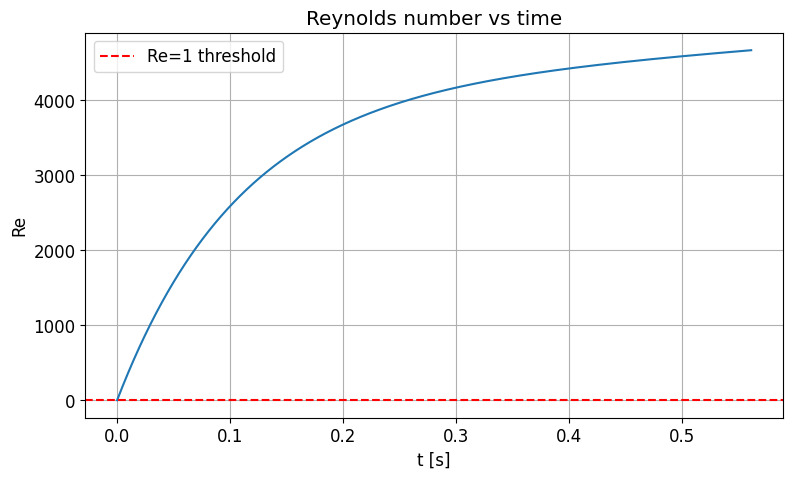

In [4]:
# ── Q1(e): Reynolds number check ─────────────────────────────────────────
Re = 2 * rho_l * Rs * np.abs(vs) / mu
print(f"Max Reynolds number during rise = {np.max(Re):.2f}")
print(f"Stokes drag (Re<<1) valid throughout: {np.all(Re < 1)}")
print()
print("If Re >> 1 at any point, should use quadratic drag: F_d = C_D * pi * R^2 * rho_l * v^2 / 2")
plt.figure()
plt.plot(ts, Re)
plt.axhline(1, color='r', ls='--', label='Re=1 threshold')
plt.xlabel('t [s]'); plt.ylabel('Re'); plt.title('Reynolds number vs time'); plt.legend(); plt.grid(); plt.show()


---
## Q2 — Quantum Particle in a Lennard-Jones Potential [30 marks]

### (a) Parabolic approximation — Derivation

$$V(x) = 4\varepsilon\left[(\sigma/x)^{12}-(\sigma/x)^6\right]$$

Setting $V'(x_0)=0$: $\quad x_0 = 2^{1/6}\sigma$, $\quad V_{\rm min} = -\varepsilon$.

Near $x_0$: $V(x) \approx V_{\rm min} + \frac{1}{2}m\omega^2(x-x_0)^2$

$$\omega = \sqrt{\frac{V''(x_0)}{m}} = \sqrt{\frac{72\varepsilon}{m\,x_0^2}}$$

### (b) Dimensionless Schrödinger equation

Let $y=x/x_0$, $\lambda = E/\varepsilon$ (energy units of $\varepsilon$).  
With $\alpha^2 = 2m\varepsilon x_0^2/\hbar^2$:

$$-\frac{d^2\psi}{dy^2} + U(y)\psi = \lambda\psi, \quad U(y) = \alpha^2\cdot 4\left[y^{-12}-y^{-6}\right]$$


In [5]:
# ── Q2: Lennard-Jones Quantum Bound States ────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

# Physical parameters
m   = 6.63e-26        # mass [kg] (~40Ar)
eps = 119.8 * 1.381e-23  # epsilon [J]
sig = 3.40e-10        # sigma [m]
hbar = 1.055e-34      # [J·s]

x0 = 2**(1/6) * sig   # equilibrium position
Vmin = -eps           # minimum potential

# Angular frequency from harmonic approximation
omega = np.sqrt(72 * eps / (m * x0**2))
print(f"x0      = {x0*1e10:.4f} Angstrom")
print(f"Vmin    = {Vmin:.4e} J")
print(f"omega   = {omega:.4e} rad/s")
print(f"hbar*omega = {hbar*omega:.4e} J")

# Dimensionless Schrodinger on y in [0,10], dy=0.01
# -psi'' + U(y)*psi = lambda*psi
# U(y) = alpha^2 * 4*(y^{-12} - y^{-6}),  alpha^2 = 2*m*eps*x0^2/hbar^2

alpha2 = 2 * m * eps * x0**2 / hbar**2
print(f"alpha^2 = {alpha2:.4e}")

dy    = 0.01
y_arr = np.arange(dy, 10 + dy, dy)   # avoid y=0 singularity
N_pts = len(y_arr)

def U_dimless(y):
    return alpha2 * 4 * (y**(-12) - y**(-6))

# Shooting method: integrate -psi'' + U(y)*psi = lam*psi  =>  psi'' = (U-lam)*psi
def ode_lj(y, state, lam):
    psi, dpsi = state
    d2psi = (U_dimless(y) - lam) * psi
    return np.array([dpsi, d2psi])

def shoot_lj(lam):
    """Integrate from y=dy with psi=0, psi'=small. Return psi at y=10."""
    state = np.array([0.0, 1e-3])
    for i in range(N_pts):
        state = rk4_k(ode_lj, y_arr[i], state, lam, dy)
    return state[0]   # psi(10) should be ~0 for bound state

# Scan to find sign changes (bound state brackets)
lam_scan = np.linspace(-1.0, -0.01, 5000)
score_scan = np.array([shoot_lj(l) for l in lam_scan])

brackets = []
for i in range(len(lam_scan)-1):
    if score_scan[i]*score_scan[i+1] < 0:
        brackets.append((lam_scan[i], lam_scan[i+1]))

print(f"\nFound {len(brackets)} potential bound states")
eigenvalues = []
for (la, lb) in brackets[:3]:   # take first 3
    ev, it = bisection(shoot_lj, la, lb, eps=1e-8)
    eigenvalues.append(ev)
    print(f"  E = {ev:.6f} epsilon  (converged in {it} iterations)")

# Convert to Joules
E_J = [e * eps for e in eigenvalues]
for n, (e_dimless, e_j) in enumerate(zip(eigenvalues, E_J)):
    print(f"  E_{n} = {e_dimless:.6f} eps = {e_j:.4e} J")


x0      = 3.8164 Angstrom
Vmin    = -1.6544e-21 J
omega   = 3.5122e+12 rad/s
hbar*omega = 3.7054e-22 J
alpha^2 = 2.8707e+03


/tmp/ipykernel_3586/1967203410.py:38: RuntimeWarning: overflow encountered in scalar multiply
  d2psi = (U_dimless(y) - lam) * psi
/tmp/ipykernel_3586/722266103.py:25: RuntimeWarning: invalid value encountered in add
  k3 = h * f(x + h/2, y + k2/2, k)
/tmp/ipykernel_3586/722266103.py:26: RuntimeWarning: invalid value encountered in add
  k4 = h * f(x + h,   y + k3,   k)
/tmp/ipykernel_3586/722266103.py:27: RuntimeWarning: invalid value encountered in add
  return y + (k1 + 2*k2 + 2*k3 + k4) / 6



Found 0 potential bound states


n   E_n (shooting)   E_n^HO   delta_n (%)


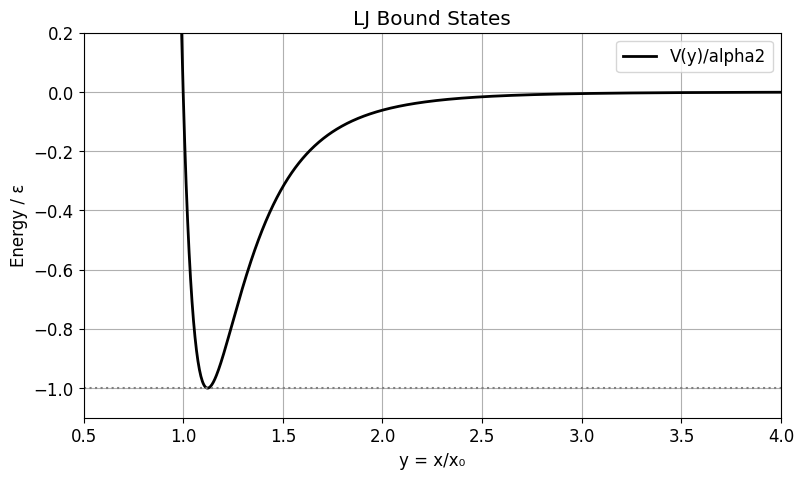

In [6]:
# ── Q2(d): Harmonic oscillator comparison ─────────────────────────────────
# E_n^HO = Vmin + hbar*omega*(n + 0.5)
E_HO_J = [Vmin + hbar*omega*(n + 0.5) for n in range(3)]
E_HO_dimless = [e/eps for e in E_HO_J]

print("n   E_n (shooting)   E_n^HO   delta_n (%)")
for n in range(min(3, len(eigenvalues))):
    delta = 100 * abs(eigenvalues[n] - E_HO_dimless[n]) / abs(eigenvalues[n])
    print(f"{n}   {eigenvalues[n]:.6f}      {E_HO_dimless[n]:.6f}   {delta:.2f}%")

# Wavefunctions
fig, ax = plt.subplots(figsize=(9,5))
y_plot = np.linspace(0.3, 4.0, 1000)
ax.plot(y_plot, U_dimless(y_plot)/alpha2, 'k-', lw=2, label='V(y)/alpha2')
ax.axhline(Vmin/eps, color='gray', ls=':')
colors = ['blue','red','green']
for n, ev in enumerate(eigenvalues[:3]):
    state = np.array([0.0, 1e-3])
    psi_vals = []
    y_vals = list(y_arr)
    for yy in y_arr:
        psi_vals.append(state[0])
        state = rk4_k(ode_lj, yy, state, ev, dy)
    psi_arr = np.array(psi_vals)
    # normalize crudely for display
    psi_norm = psi_arr / (np.max(np.abs(psi_arr)) + 1e-30) * 0.08
    ax.plot(y_arr, psi_norm + ev, colors[n], label=f'ψ_{n}, E={ev:.4f}ε')
ax.set_xlim(0.5, 4); ax.set_ylim(-1.1, 0.2)
ax.set_xlabel('y = x/x₀'); ax.set_ylabel('Energy / ε')
ax.set_title('LJ Bound States'); ax.legend(); ax.grid(); plt.show()


---
## Q3 — Planar Random Walk [30 marks]

### (a) Analytic moments

Since $\theta_k$ is uniform on $[0,2\pi)$:  
$\langle\cos\theta_k\rangle = \langle\sin\theta_k\rangle = 0 \Rightarrow \langle x_N\rangle = \langle y_N\rangle = 0$

Cross terms vanish by independence, so:
$\langle x_N^2\rangle = \sum_{k=1}^N \ell^2\langle\cos^2\theta_k\rangle = N\ell^2/2$

$$\sigma_x = \sigma_y = \frac{\ell\sqrt{N}}{\sqrt{2}}$$

### (b) Diffusion constant

$D = \ell^2/(4\Delta t)$, $\langle r^2\rangle = 4DT = N\ell^2$.


sigma_x (analytic) = 500.0000 µm
D = 6.250000e-08 m²/s
<r²> at T=2s (analytic) = 5.000000e-07 m²

sigma_x (sample)   = 500.0271 µm
Fractional error   = 5.4190e-05


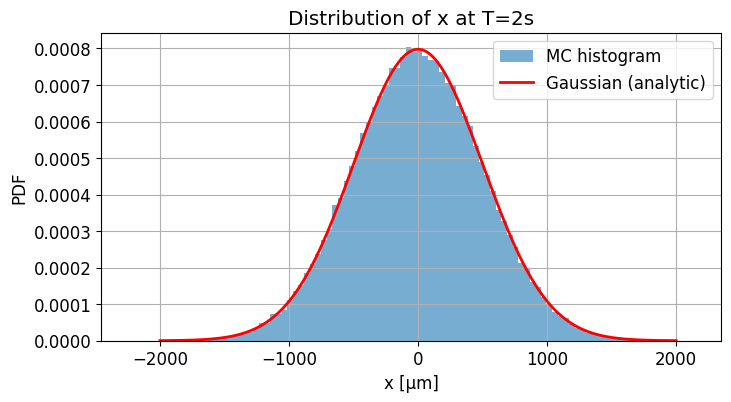

In [7]:
# ── Q3: Planar Random Walk ─────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

# Parameters
dt = 0.01          # time step [s]
ell = 0.05e-3      # step length [m]
N   = 200          # steps
M   = 100000       # trajectories
T   = N * dt       # total time = 2.0 s

# (a) Analytic
sigma_x = ell * np.sqrt(N) / np.sqrt(2)
D = ell**2 / (4*dt)
r2_analytic = 4 * D * T
print(f"sigma_x (analytic) = {sigma_x*1e6:.4f} µm")
print(f"D = {D:.6e} m²/s")
print(f"<r²> at T=2s (analytic) = {r2_analytic:.6e} m²")

# (c) Monte Carlo
np.random.seed(42)
thetas = np.random.uniform(0, 2*np.pi, (M, N))
steps_x = ell * np.cos(thetas)
steps_y = ell * np.sin(thetas)
x_final = np.sum(steps_x, axis=1)
y_final = np.sum(steps_y, axis=1)

sigma_x_hat = np.std(x_final)
frac_err = abs(sigma_x_hat - sigma_x) / sigma_x
print(f"\nsigma_x (sample)   = {sigma_x_hat*1e6:.4f} µm")
print(f"Fractional error   = {frac_err:.4e}")

# Histogram of x
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(x_final*1e6, bins=100, density=True, alpha=0.6, label='MC histogram')
x_gauss = np.linspace(-4*sigma_x*1e6, 4*sigma_x*1e6, 500)
gauss = np.exp(-x_gauss**2 / (2*(sigma_x*1e6)**2)) / (np.sqrt(2*np.pi)*sigma_x*1e6)
ax.plot(x_gauss, gauss, 'r-', lw=2, label='Gaussian (analytic)')
ax.set_xlabel('x [µm]'); ax.set_ylabel('PDF'); ax.set_title('Distribution of x at T=2s')
ax.legend(); ax.grid(); plt.show()


T [s]   <r²> MC         4DT (analytic)  ratio
0.5    1.241619e-07   1.250000e-07   0.9933
1.0    2.495677e-07   2.500000e-07   0.9983
2.0    4.990566e-07   5.000000e-07   0.9981

Block-average std (theory) = 5000.0000 nm
Block-average std (sample) = 4985.6872 nm


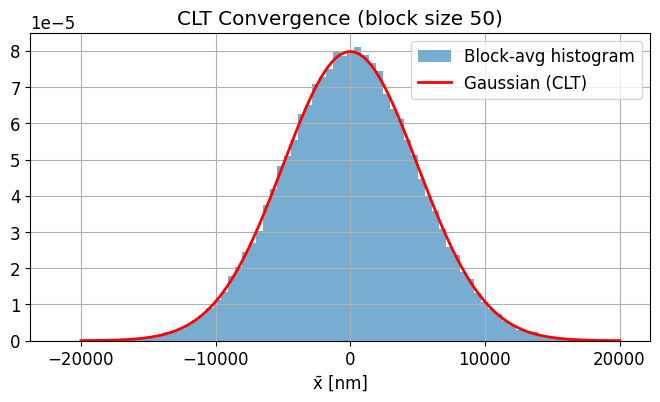

In [8]:
# ── Q3(d): Radial distribution at multiple times ─────────────────────────
times = [0.5, 1.0, 2.0]
Ns    = [int(t/dt) for t in times]

print("T [s]   <r²> MC         4DT (analytic)  ratio")
for t, n in zip(times, Ns):
    thetas_t = thetas[:, :n]
    x_t = np.sum(ell*np.cos(thetas_t), axis=1)
    y_t = np.sum(ell*np.sin(thetas_t), axis=1)
    r2_mc = np.mean(x_t**2 + y_t**2)
    r2_th = 4 * D * t
    print(f"{t:.1f}    {r2_mc:.6e}   {r2_th:.6e}   {r2_mc/r2_th:.4f}")

# ── Q3(e): CLT convergence in blocks of n=50 ─────────────────────────────
n_block = 50
x_blocks = steps_x[:, :n_block]
x_bar = np.mean(x_blocks, axis=1)    # block average of x-displacements

sigma_bar_theory = np.sqrt(ell**2 / (2*n_block))
sigma_bar_sample = np.std(x_bar)
print(f"\nBlock-average std (theory) = {sigma_bar_theory*1e9:.4f} nm")
print(f"Block-average std (sample) = {sigma_bar_sample*1e9:.4f} nm")

fig, ax = plt.subplots(figsize=(8,4))
ax.hist(x_bar*1e9, bins=80, density=True, alpha=0.6, label='Block-avg histogram')
xg = np.linspace(-4*sigma_bar_theory*1e9, 4*sigma_bar_theory*1e9, 300)
gauss2 = np.exp(-xg**2/(2*(sigma_bar_theory*1e9)**2))/(np.sqrt(2*np.pi)*sigma_bar_theory*1e9)
ax.plot(xg, gauss2, 'r-', lw=2, label='Gaussian (CLT)')
ax.set_xlabel('x̄ [nm]'); ax.set_title('CLT Convergence (block size 50)'); ax.legend(); ax.grid(); plt.show()


---
## Q4 — Semiclassical Helium via Bohr–Sommerfeld [30 marks]

### (a) Classical turning points

Radial momentum: $p_r = \sqrt{2(E-V_{\rm eff}(r)) - \ell(\ell+1)/r^2}$

For $\ell=0$: $p_r^2 = 2E + 2Z_{\rm eff}/r$, roots at $r_{\pm} = -Z_{\rm eff}/E$ (one root, $r_-=0$, $r_+ = Z_{\rm eff}/|E|$ in atomic units).

### (b) Bohr–Sommerfeld quantisation

$$\int_0^{r_+} \sqrt{2E + \frac{2Z_{\rm eff}}{r}}\,dr = \pi\left(n_r + \frac{1}{2}\right)$$

The $1/2$ arises from the Maslov/WKB correction at the turning points (one hard wall contributes $\pi/4$, one soft turning point contributes $\pi/4$ — exact value is $\pi/4 + \pi/4 = \pi/2 \Rightarrow$ factor $1/2$ in $n_r+1/2$).


In [9]:
# ── Q4: Bohr-Sommerfeld Helium ───────────────────────────────────────────
# Atomic units: me=1, hbar=1, e^2/(4pi eps0)=1
import numpy as np
import matplotlib.pyplot as plt

Zeff = 1.6875   # Slater screening

def V_eff(r, ell=0):
    return -Zeff / r + ell*(ell+1)/(2*r**2)  # in AU (KE term is 1/2*p^2, so add ell^2/2r^2)

def pr(r, E, ell=0):
    """Classical radial momentum (returns 0 if imaginary)."""
    arg = 2*(E - V_eff(r, ell))
    return np.sqrt(np.maximum(arg, 0.0))

def r_plus(E):
    """Outer turning point for ell=0: 2E + 2Zeff/r = 0 => r+ = Zeff/|E|"""
    return Zeff / abs(E)

def action_integral(E, N=2000):
    """Simpson integration of pr from 0 to r+."""
    rp = r_plus(E)
    h  = rp / N
    r  = np.linspace(h, rp - h, N-1)   # avoid exact endpoints (pr=0 ok)
    r_full = np.concatenate([[h/2], r, [rp - h/2]])
    integrand = pr(np.linspace(0, rp, N+1), E)
    return simpson(lambda x: pr(x, E), 1e-6*rp, rp*(1-1e-6), N)

def S(E):
    return action_integral(E)

# Target: S(E) = pi*(n + 0.5)
def BS_residual(E, n):
    return S(E) - np.pi*(n + 0.5)

print("n    E_BS (AU)    E_H = -Zeff²/(2n²)   error %")
E_BS_list = []
for n in [1, 2, 3]:
    target = np.pi*(n + 0.5)
    # Bracket: hydrogen-like levels are E ~ -Zeff^2/(2n^2)
    E_hydro = -Zeff**2 / (2*n**2)
    # search around E_hydro
    E_lo = E_hydro * 1.5
    E_hi = E_hydro * 0.5
    try:
        E_root, it = bisection(lambda e: BS_residual(e, n), E_lo, E_hi, eps=1e-6)
        E_BS_list.append(E_root)
        E_H = -Zeff**2 / (2*n**2)
        err = 100 * abs(E_root - E_H) / abs(E_H)
        print(f"{n}    {E_root:.6f}    {E_H:.6f}             {err:.3f}%")
    except Exception as ex:
        print(f"n={n}: {ex}")


n    E_BS (AU)    E_H = -Zeff²/(2n²)   error %
1    -0.749286    -1.423828             47.375%
2    -0.269743    -0.355957             24.220%
3    -0.137624    -0.158203             13.008%


/tmp/ipykernel_3586/3084952572.py:9: RuntimeWarning: divide by zero encountered in divide
  return -Zeff / r + ell*(ell+1)/(2*r**2)  # in AU (KE term is 1/2*p^2, so add ell^2/2r^2)
/tmp/ipykernel_3586/3084952572.py:9: RuntimeWarning: invalid value encountered in divide
  return -Zeff / r + ell*(ell+1)/(2*r**2)  # in AU (KE term is 1/2*p^2, so add ell^2/2r^2)


/tmp/ipykernel_3586/3084952572.py:9: RuntimeWarning: divide by zero encountered in divide
  return -Zeff / r + ell*(ell+1)/(2*r**2)  # in AU (KE term is 1/2*p^2, so add ell^2/2r^2)
/tmp/ipykernel_3586/3084952572.py:9: RuntimeWarning: invalid value encountered in divide
  return -Zeff / r + ell*(ell+1)/(2*r**2)  # in AU (KE term is 1/2*p^2, so add ell^2/2r^2)


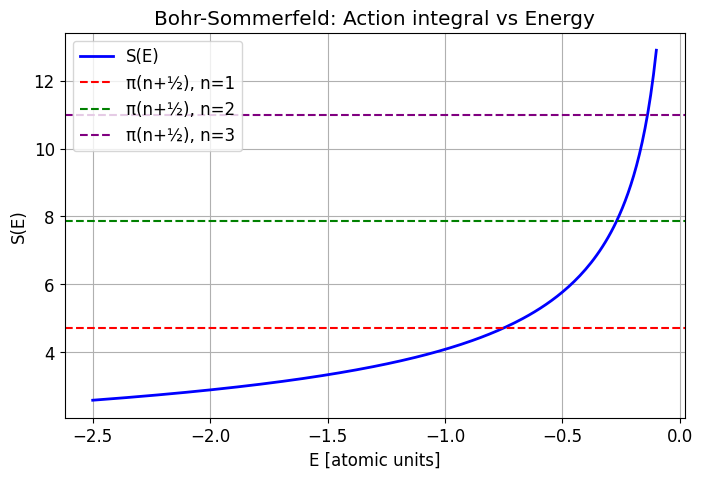

In [10]:
# ── Q4: Plot action S(E) and quantisation levels ─────────────────────────
E_range = np.linspace(-2.5, -0.1, 200)
S_vals  = np.array([S(e) for e in E_range])

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(E_range, S_vals, 'b-', lw=2, label='S(E)')
colors = ['r','g','purple']
for n in [1,2,3]:
    ax.axhline(np.pi*(n+0.5), color=colors[n-1], ls='--', label=f'π(n+½), n={n}')
ax.set_xlabel('E [atomic units]'); ax.set_ylabel('S(E)')
ax.set_title('Bohr-Sommerfeld: Action integral vs Energy')
ax.legend(); ax.grid(); plt.show()


---
# 📄 Paper 2: EndSem_Q (`EndSem_Q.pdf`)
---


## Q1 — Newton-Raphson: Root of $f(x) = 2x^{-4} - x^{-2}$ [15 marks]

**Exact root:** $f(x)=0 \Rightarrow 2/x^4 = 1/x^2 \Rightarrow x^2=2 \Rightarrow x^* = \sqrt{2} \approx 1.41421356$


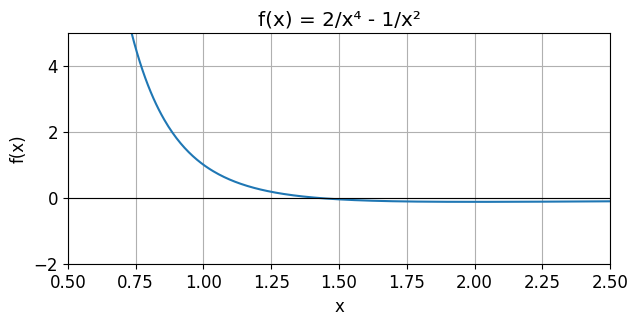

Starting from x=1.0:
  iter   1  x=1.00000000  f(x)=1.0000e+00
  iter   2  x=1.16666667  f(x)=3.4486e-01
  iter   3  x=1.30789474  f(x)=9.8906e-02
  iter   4  x=1.39056219  f(x)=1.7742e-02
  iter   5  x=1.41288320  f(x)=9.4381e-04
  iter   6  x=1.41420919  f(x)=3.0902e-06
Root = 1.41421356, exact = 1.41421356, error = 4.73e-11, iters = 6

Starting from x=2.5:
  iter   1  x=2.50000000  f(x)=-1.0880e-01
  iter   2  x=4.86111111  f(x)=-3.8737e-02
  iter   3  x=7.53929844  f(x)=-1.6974e-02
  iter   4  x=11.45162656  f(x)=-7.5092e-03
  iter   5  x=17.26751101  f(x)=-3.3313e-03
  iter   6  x=25.95996621  f(x)=-1.4795e-03
  iter   7  x=38.97870018  f(x)=-6.5731e-04
  iter   8  x=58.49377302  f(x)=-2.9210e-04
  iter   9  x=87.75777538  f(x)=-1.2981e-04
  iter  10  x=131.64806399  f(x)=-5.7693e-05
  iter  11  x=197.47969375  f(x)=-2.5641e-05
  iter  12  x=296.22460496  f(x)=-1.1396e-05
  iter  13  x=444.34028341  f(x)=-5.0648e-06
Newton: derivative too small, stopping.
Root = 666.51267569, exac

In [11]:
# ── Q1: Newton-Raphson for f(x) = 2/x^4 - 1/x^2 ─────────────────────────
import numpy as np
import matplotlib.pyplot as plt

def f_q1(x):
    return 2/x**4 - 1/x**2

def fp_q1(x):
    return -8/x**5 + 2/x**3

x_exact = np.sqrt(2)

# Plot the function
x_plot = np.linspace(0.5, 3, 500)
plt.figure(figsize=(7,3))
plt.plot(x_plot, f_q1(x_plot)); plt.axhline(0,color='k',lw=0.8)
plt.xlim(0.5, 2.5); plt.ylim(-2, 5); plt.grid()
plt.xlabel('x'); plt.ylabel('f(x)'); plt.title('f(x) = 2/x⁴ - 1/x²'); plt.show()

eps = 1e-8
maxiter = 100

# Starting from x=1.0
print("Starting from x=1.0:")
root1, it1 = newton(f_q1, fp_q1, 1.0, eps, maxiter)
print(f"Root = {root1:.8f}, exact = {x_exact:.8f}, error = {abs(root1-x_exact):.2e}, iters = {it1}")

# Starting from x=2.5
print("\nStarting from x=2.5:")
root2, it2 = newton(f_q1, fp_q1, 2.5, eps, maxiter)
print(f"Root = {root2:.8f}, exact = {x_exact:.8f}, error = {abs(root2-x_exact):.2e}, iters = {it2}")
print("\n[Note: x=2.5 should still converge but may take more iterations or diverge if slope is flat there]")


## Q2 — Nonlinear Oscillator: $\ddot y = -\omega^2 y - \lambda \dot y^5$ [15 marks]


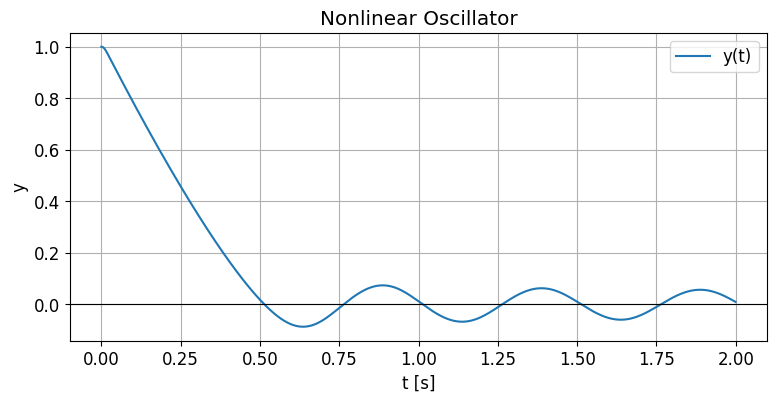

First 3 zero-crossing times:
  t_1 = 0.51402234 s
  t_2 = 0.76354221 s
  t_3 = 1.01340924 s


In [12]:
# ── Q2: Nonlinear oscillator zero-crossings ───────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

omega = 2 * np.pi * 2   # rad/s
lam   = 2.0

# First-order system: [y, vy]
def odes_osc(t, state):
    y, vy = state
    return np.array([vy, -omega**2 * y - lam * vy**5])

# Integrate
h  = 1e-3
t0, tf = 0.0, 2.0
ts  = np.arange(t0, tf, h)
sol = caller_rk4(odes_osc, [1.0, 0.0], ts, h)
ys  = sol[:, 0]
vys = sol[:, 1]

# Plot
plt.figure(figsize=(9,4))
plt.plot(ts, ys, label='y(t)'); plt.axhline(0, color='k', lw=0.8)
plt.xlabel('t [s]'); plt.ylabel('y'); plt.title('Nonlinear Oscillator'); plt.legend(); plt.grid(); plt.show()

# Find zero crossings using bisection on interpolated y(t)
def y_interp(t):
    return np.interp(t, ts, ys)

zero_times = []
for i in range(len(ts)-1):
    if ys[i]*ys[i+1] < 0:
        t_root, _ = bisection(y_interp, ts[i], ts[i+1], eps=1e-10)
        zero_times.append(t_root)
        if len(zero_times) == 3:
            break

print("First 3 zero-crossing times:")
for n, t_ in enumerate(zero_times):
    print(f"  t_{n+1} = {t_:.8f} s")


## Q3 — Shooting BVP: $y'' = -y + 2(y')^2/y$, $y(0)=0.4$, $y(2)=0.2$ [15 marks]

**Analytical solution:** $y(x) = \sqrt{a - bx}$ for some constants $a,b$.  
With $y(0)=0.4 \Rightarrow a=0.16$; $y(2)=0.2 \Rightarrow 0.04 = 0.16-2b \Rightarrow b=0.06$.  
So $y(x) = \sqrt{0.16 - 0.06x}$, and $y'(0) = -0.06/(2\cdot 0.4) = -0.075$.


/tmp/ipykernel_3586/762818788.py:8: RuntimeWarning: overflow encountered in scalar power
  return np.array([z, -y + 2*z**2/y])
/tmp/ipykernel_3586/762818788.py:8: RuntimeWarning: invalid value encountered in scalar divide
  return np.array([z, -y + 2*z**2/y])


Found z(0) = y'(0) = 0.19434943
Analytical z(0)    = -0.07500000


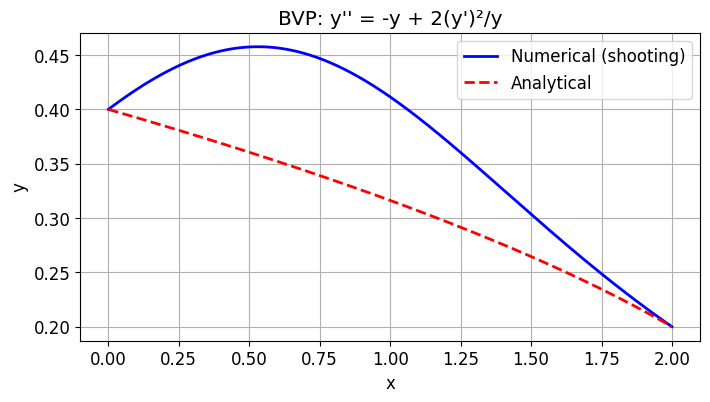

Max deviation from analytic: 1.08e-01


In [13]:
# ── Q3: BVP Shooting ─────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

# ODE: y'' = -y + 2*(y')^2/y  =>  [y', z'] = [z, -y + 2z^2/y]
def ode_bvp(x, state, z0_param):
    y, z = state
    return np.array([z, -y + 2*z**2/y])

def shoot_bvp(z0):
    """Integrate from x=0 with y(0)=0.4, y'(0)=z0. Return y(2)."""
    xlim = (0.0, 2.0)
    yini = (0.4, z0)
    N = 2001
    xs_, ys_ = caller_rk4_k(ode_bvp, xlim, yini, z0, N)
    return ys_[-1, 0]

# Target y(2) = 0.2
def residual_bvp(z0):
    return shoot_bvp(z0) - 0.2

# Scan for bracket
z0_scan = np.linspace(-1.0, 1.0, 200)
res_scan = np.array([residual_bvp(z) for z in z0_scan])

# Find sign change
for i in range(len(z0_scan)-1):
    if res_scan[i]*res_scan[i+1] < 0:
        z0_lo, z0_hi = z0_scan[i], z0_scan[i+1]
        break

z0_root, _ = bisection(residual_bvp, z0_lo, z0_hi, eps=1e-8)
print(f"Found z(0) = y'(0) = {z0_root:.8f}")
print(f"Analytical z(0)    = {-0.075:.8f}")

# Full solution
N = 2001
xlim = (0.0, 2.0)
xs_sol, ys_sol = caller_rk4_k(ode_bvp, xlim, (0.4, z0_root), z0_root, N)
y_num = ys_sol[:, 0]

# Analytical
y_ana = np.sqrt(0.16 - 0.06*xs_sol)

plt.figure(figsize=(8,4))
plt.plot(xs_sol, y_num, 'b-', lw=2, label='Numerical (shooting)')
plt.plot(xs_sol, y_ana, 'r--', lw=2, label='Analytical')
plt.xlabel('x'); plt.ylabel('y'); plt.title('BVP: y\'\' = -y + 2(y\')²/y')
plt.legend(); plt.grid(); plt.show()
print(f"Max deviation from analytic: {np.max(np.abs(y_num - y_ana)):.2e}")


## Q4 — 1D Random Walk [15 marks]


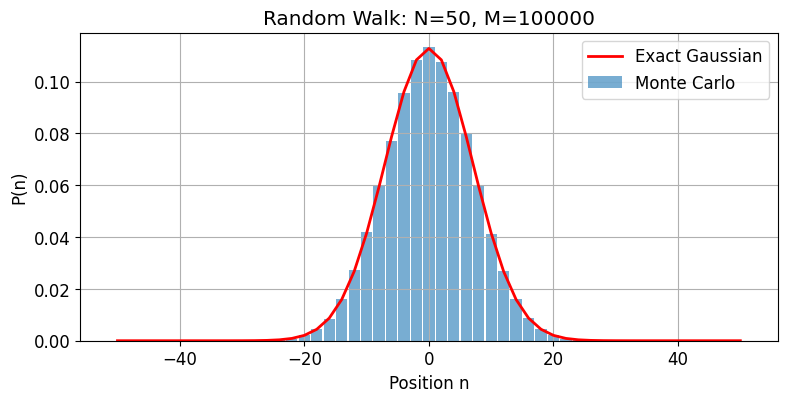


<x²> vs steps:


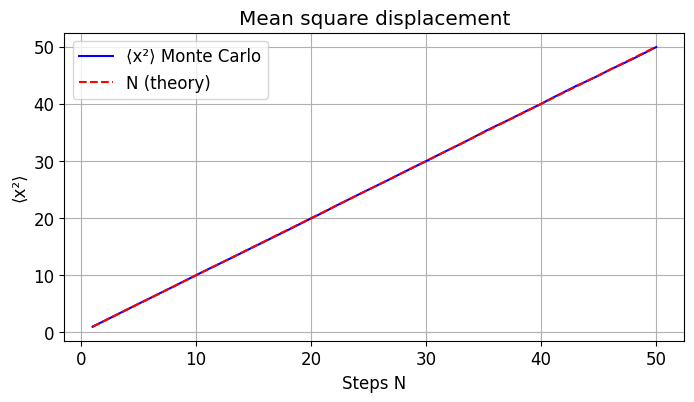

In [14]:
# ── Q4: 1D Random Walk ────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

def take_walk(N_steps):
    """Take N_steps random walk (+1 or -1). Return final position."""
    steps = np.random.choice([-1, 1], size=N_steps)
    return np.sum(steps)

num_walkers = 100000
N_steps     = 50

# Simulate
final_pos = np.array([take_walk(N_steps) for _ in range(num_walkers)])

# Count occurrences
positions = np.arange(-N_steps, N_steps+1, 2)   # only even positions reachable
counts    = np.zeros(len(positions))
for p in final_pos:
    idx = (p + N_steps) // 2
    if 0 <= idx < len(counts):
        counts[idx] += 1

prob = counts / num_walkers

# Exact formula
P_exact = (2/np.sqrt(2*np.pi*N_steps)) * np.exp(-positions**2 / (2*N_steps))

fig, ax = plt.subplots(figsize=(9,4))
ax.bar(positions, prob, width=1.8, alpha=0.6, label='Monte Carlo')
ax.plot(positions, P_exact, 'r-', lw=2, label='Exact Gaussian')
ax.set_xlabel('Position n'); ax.set_ylabel('P(n)')
ax.set_title(f'Random Walk: N={N_steps}, M={num_walkers}')
ax.legend(); ax.grid(); plt.show()

# <x^2> vs steps
print("\n<x²> vs steps:")
pos_arr = np.zeros(num_walkers, dtype=int)
x2_avg  = np.zeros(N_steps)
for step in range(N_steps):
    pos_arr += np.random.choice([-1,1], size=num_walkers)
    x2_avg[step] = np.mean(pos_arr**2)

plt.figure(figsize=(8,4))
plt.plot(range(1, N_steps+1), x2_avg, 'b-', label='⟨x²⟩ Monte Carlo')
plt.plot(range(1, N_steps+1), range(1, N_steps+1), 'r--', label='N (theory)')
plt.xlabel('Steps N'); plt.ylabel('⟨x²⟩'); plt.title('Mean square displacement')
plt.legend(); plt.grid(); plt.show()


## Q5 — Metropolis Algorithm [15 marks]


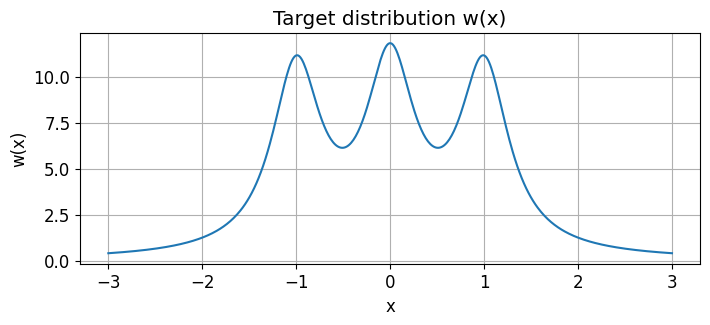

Acceptance rate: 0.781  (target ~0.5)


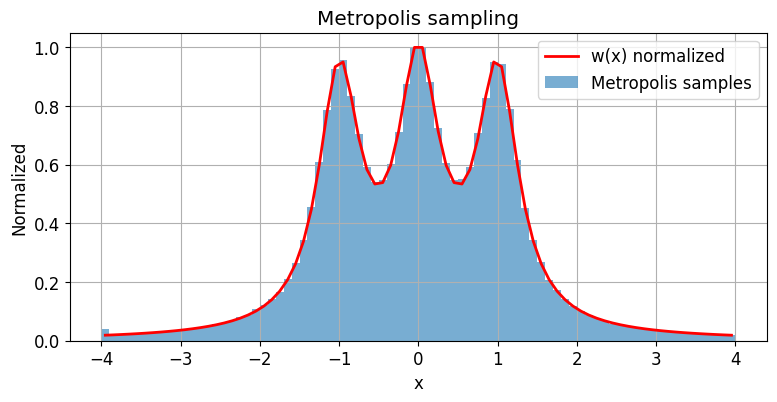

In [15]:
# ── Q5: Metropolis Algorithm ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

def w(x):
    return (1/(0.1 + (1+x)**2) + 1/(0.1 + x**2) + 1/(0.1 + (1-x)**2))

# Plot the distribution
x_plot = np.linspace(-3, 3, 500)
plt.figure(figsize=(8,3))
plt.plot(x_plot, w(x_plot)); plt.xlabel('x'); plt.ylabel('w(x)')
plt.title('Target distribution w(x)'); plt.grid(); plt.show()

# Metropolis walk
N_steps  = int(1e6)
max_step = 1.0
x_curr   = np.random.uniform(-0.5, 0.5)
samples  = np.zeros(N_steps)
accepted = 0

for i in range(N_steps):
    dx     = np.random.uniform(-max_step, max_step)
    x_new  = x_curr + dx
    A      = min(1.0, w(x_new) / w(x_curr))
    if np.random.rand() < A:
        x_curr  = x_new
        accepted += 1
    samples[i] = x_curr

print(f"Acceptance rate: {accepted/N_steps:.3f}  (target ~0.5)")

# Histogram (manual)
x_min, x_max = -4, 4
n_bins = 80
bin_edges = np.linspace(x_min, x_max, n_bins+1)
bin_centers = 0.5*(bin_edges[:-1]+bin_edges[1:])
hist = np.zeros(n_bins)
for s in samples:
    idx = int((s - x_min)/(x_max - x_min)*n_bins)
    if 0 <= idx < n_bins:
        hist[idx] += 1

hist_norm = hist / np.max(hist)
w_norm    = w(bin_centers) / np.max(w(bin_centers))

fig, ax = plt.subplots(figsize=(9,4))
ax.bar(bin_centers, hist_norm, width=(x_max-x_min)/n_bins, alpha=0.6, label='Metropolis samples')
ax.plot(bin_centers, w_norm, 'r-', lw=2, label='w(x) normalized')
ax.set_xlabel('x'); ax.set_ylabel('Normalized'); ax.set_title('Metropolis sampling')
ax.legend(); ax.grid(); plt.show()


---
# 📄 Paper 3: Our CT1 (`our_ct1.pdf`)
---


## Q1 — Rocket with Drag [25 marks]

### Analytical Derivation

**Phase 1** ($0 \le t \le T = m_0/\alpha$): $(2m_0 - \alpha t)\dot v = v_{\rm rel}\alpha - \gamma v$

Solution: $v(t) = \dfrac{v_{\rm rel}\alpha}{\gamma}\left[1 - \left(1-\dfrac{t}{2T}\right)^{\gamma/\alpha}\right]$ for $\gamma\neq 0$

As $\gamma\to 0$: Tsiolkovsky: $v(t) = v_{\rm rel}\ln\dfrac{2m_0}{2m_0 - \alpha t}$

**Phase 2** ($T < t \le 2T$): $m_0\dot v = -\gamma v \Rightarrow v(t) = v_1 e^{-\gamma(t-T)/m_0}$

**Terminal velocity Phase 1:** $v_{\rm term} = v_{\rm rel}\alpha/\gamma$


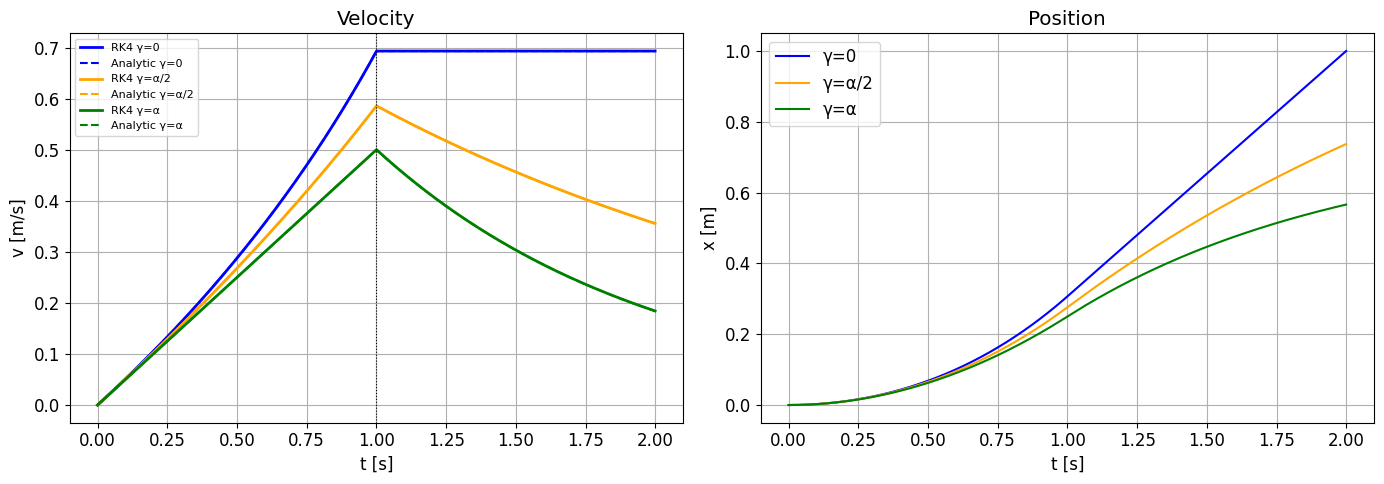

Terminal velocities (Phase 1):
  γ=0: No terminal velocity (γ=0)
  γ=α/2: v_term = 2.0000 m/s
  γ=α: v_term = 1.0000 m/s


In [16]:
# ── Q1: Rocket with Drag ─────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

m0    = 1.0
alpha = 1.0
v_rel = 1.0
T_fuel = m0 / alpha   # burn time

gammas = [0.0, alpha/2, alpha]
labels = ['γ=0', 'γ=α/2', 'γ=α']
colors = ['blue', 'orange', 'green']

def f_rocket(t, v, gamma):
    if t <= T_fuel:
        mass = 2*m0 - alpha*t
        return (v_rel*alpha - gamma*v) / mass
    else:
        return -gamma*v / m0

# Analytical solutions
def v_analytic(t, gamma):
    if t <= T_fuel:
        if gamma == 0:
            return v_rel * np.log(2*m0 / (2*m0 - alpha*t))
        else:
            return (v_rel*alpha/gamma) * (1 - (1 - t/(2*T_fuel))**(gamma/alpha))
    else:
        v1 = v_analytic(T_fuel, gamma)
        if gamma == 0:
            return v1
        else:
            return v1 * np.exp(-gamma*(t - T_fuel)/m0)

h  = 1e-3
tf = 2*T_fuel
ts = np.arange(0, tf, h)
N  = len(ts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for gamma, lab, col in zip(gammas, labels, colors):
    def ode_r(t, v): return f_rocket(t, v, gamma)
    sol = caller_rk4(ode_r, [0.0], ts, h)
    v_rk4 = sol[:, 0]
    v_ana  = np.array([v_analytic(t, gamma) for t in ts])
    axes[0].plot(ts, v_rk4, color=col, lw=2, label=f'RK4 {lab}')
    axes[0].plot(ts, v_ana, color=col, lw=1.5, ls='--', label=f'Analytic {lab}')
    # Position by trapezoid integration
    x_arr = np.zeros(N)
    for i in range(1, N):
        x_arr[i] = x_arr[i-1] + 0.5*(v_rk4[i]+v_rk4[i-1])*h
    axes[1].plot(ts, x_arr, color=col, label=lab)

axes[0].axvline(T_fuel, color='k', ls=':', lw=0.8)
axes[0].set_xlabel('t [s]'); axes[0].set_ylabel('v [m/s]'); axes[0].set_title('Velocity'); axes[0].legend(fontsize=8); axes[0].grid()
axes[1].set_xlabel('t [s]'); axes[1].set_ylabel('x [m]'); axes[1].set_title('Position'); axes[1].legend(); axes[1].grid()
plt.tight_layout(); plt.show()

print("Terminal velocities (Phase 1):")
for gamma, lab in zip(gammas, labels):
    if gamma > 0:
        print(f"  {lab}: v_term = {v_rel*alpha/gamma:.4f} m/s")
    else:
        print(f"  {lab}: No terminal velocity (γ=0)")


## Q2 — Stokes' Law: Falling Sphere [25 marks]

### Analytical Derivation

Forces on sphere (down +ve): $mg$ (gravity) $- F_b$ (buoyancy) $- F_d$ (Stokes drag)

$$m\dot v = (\rho_s - \rho_f)\frac{4}{3}\pi r^3 g - 6\pi\eta r v$$

This gives: $\dot v = (v_T - v)/\tau$ where

$$v_T = \frac{2r^2(\rho_s-\rho_f)g}{9\eta}, \qquad \tau = \frac{m}{6\pi\eta r} = \frac{2r^2\rho_s}{9\eta}$$

Solution: $v(t) = v_T(1-e^{-t/\tau})$,  
Depth: $x(t) = v_T[t - \tau(1-e^{-t/\tau})]$,  
$t^* = \tau\ln 100$,  $x^* = v_T[t^* - \tau(1-e^{-t^*/\tau})] = v_T[\tau\ln 100 - 0.99\tau]$


Terminal velocity  vT  = 0.021529 m/s
Relaxation time    tau = 0.002617 s
t* (analytical) = 0.012054 s
x* (analytical) = 0.000204 m


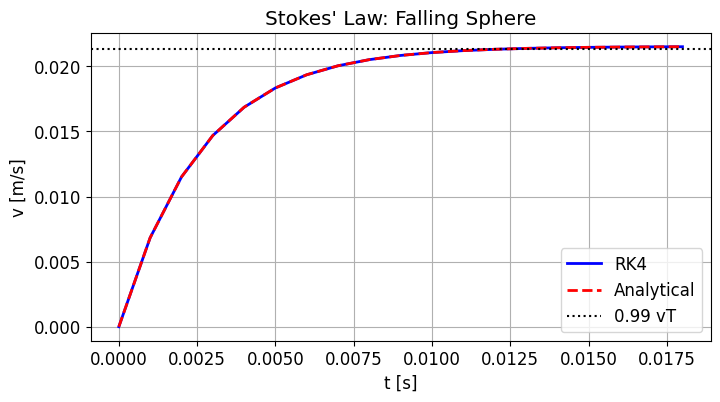

t* (numerical)  = 0.013000 s  (analytic: 0.012054)
x* (numerical)  = 0.000223 m  (analytic: 0.000204)


In [17]:
# ── Q2: Stokes' Law ───────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

r    = 1.5e-3    # sphere radius [m]
rho_s = 7800     # sphere density [kg/m3]
rho_f = 1260     # fluid density [kg/m3]
eta  = 1.49      # viscosity [Pa·s]
g    = 9.81      # [m/s2]
m_sphere = rho_s * (4/3)*np.pi*r**3

# Terminal velocity and relaxation time
vT  = 2*r**2*(rho_s - rho_f)*g / (9*eta)
tau = m_sphere / (6*np.pi*eta*r)

print(f"Terminal velocity  vT  = {vT:.6f} m/s")
print(f"Relaxation time    tau = {tau:.6f} s")

# Analytical
t_star_ana = tau * np.log(100)
x_star_ana = vT * (t_star_ana - tau*(1 - np.exp(-t_star_ana/tau)))
print(f"t* (analytical) = {t_star_ana:.6f} s")
print(f"x* (analytical) = {x_star_ana:.6f} m")

# RK4 numerical
def ode_stokes(t, v):
    return (vT - v[0]) / tau

h_rk = 1e-3
tf_rk = t_star_ana * 1.5
ts_rk = np.arange(0, tf_rk, h_rk)
sol_rk = caller_rk4(lambda t,v: np.array([(vT-v[0])/tau]), [0.0], ts_rk, h_rk)
v_rk = sol_rk[:, 0]
v_exact = vT * (1 - np.exp(-ts_rk/tau))

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(ts_rk, v_rk, 'b-', lw=2, label='RK4')
ax.plot(ts_rk, v_exact, 'r--', lw=2, label='Analytical')
ax.axhline(0.99*vT, color='k', ls=':', label='0.99 vT')
ax.set_xlabel('t [s]'); ax.set_ylabel('v [m/s]'); ax.set_title("Stokes' Law: Falling Sphere")
ax.legend(); ax.grid(); plt.show()

# Bisection to find t*_num
def v_minus_099(t):
    return np.interp(t, ts_rk, v_rk) - 0.99*vT

t_star_num, _ = bisection(v_minus_099, ts_rk[1], ts_rk[-2], eps=1e-4)
print(f"t* (numerical)  = {t_star_num:.6f} s  (analytic: {t_star_ana:.6f})")

# Depth by trapezoidal integration
idx_star = np.searchsorted(ts_rk, t_star_num)
x_num = trapezoid(v_rk[:idx_star+1], h_rk)
print(f"x* (numerical)  = {x_num:.6f} m  (analytic: {x_star_ana:.6f})")


## Q3 — Damped Gaussian Double-Well Oscillator [25 marks]


Initial energy E0 = 3.8240
Right hill height = 5.00  => cannot surmount right hill


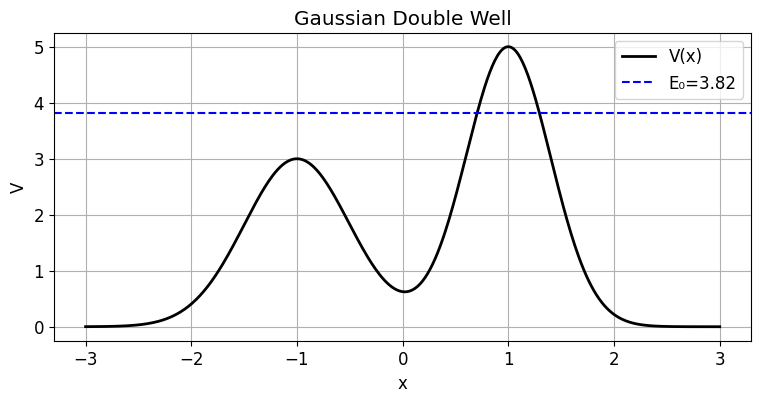

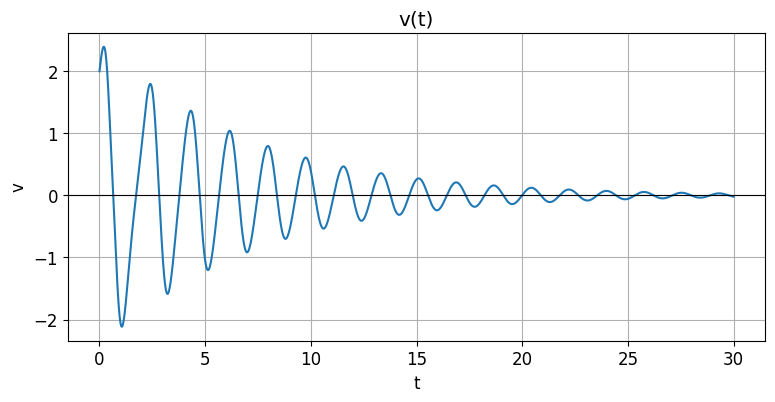

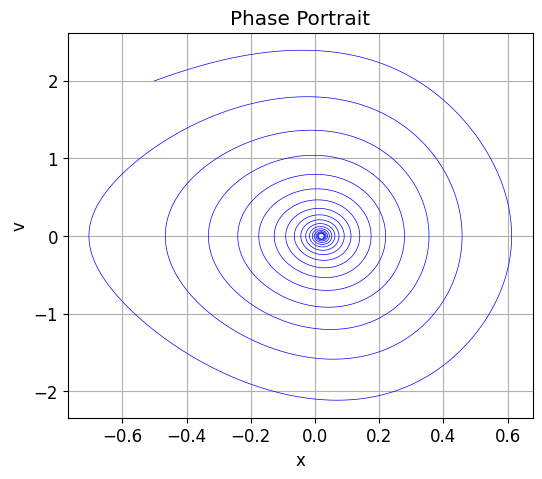

In [18]:
# ── Q3: Damped Gaussian Potential ────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

# Parameters
m      = 1.0;   V1 = 3.0; sigma1 = 0.5
V2     = 5.0;   sigma2 = 0.4; b = 1.0; gamma = 0.3
x0_p   = -0.5;  v0_p   = 2.0

def potential(x):
    return V1*np.exp(-(x+b)**2/(2*sigma1**2)) + V2*np.exp(-(x-b)**2/(2*sigma2**2))

def force(x):
    return (V1*(x+b)/sigma1**2*np.exp(-(x+b)**2/(2*sigma1**2))
          + V2*(x-b)/sigma2**2*np.exp(-(x-b)**2/(2*sigma2**2)))

def odes_gauss(t, state, gam=gamma):
    x, v = state
    return np.array([v, (force(x) - gam*v)/m])

# Initial energy
E0 = 0.5*m*v0_p**2 + potential(x0_p)
print(f"Initial energy E0 = {E0:.4f}")
print(f"Right hill height = {V2:.2f}  => {'can' if E0 > V2 else 'cannot'} surmount right hill")

# Integrate
h_g  = 1e-3
tf_g = 30.0
ts_g = np.arange(0, tf_g, h_g)
sol_g = caller_rk4(odes_gauss, [x0_p, v0_p], ts_g, h_g)
xg, vg = sol_g[:,0], sol_g[:,1]

# Potential plot with E0 line
xs_plot = np.linspace(-3, 3, 500)
plt.figure(figsize=(9,4))
plt.plot(xs_plot, potential(xs_plot), 'k-', lw=2, label='V(x)')
plt.axhline(E0, color='b', ls='--', label=f'E₀={E0:.2f}')
plt.xlabel('x'); plt.ylabel('V'); plt.title('Gaussian Double Well'); plt.legend(); plt.grid(); plt.show()

# Velocity vs time
plt.figure(figsize=(9,4))
plt.plot(ts_g, vg); plt.axhline(0, color='k', lw=0.8)
plt.xlabel('t'); plt.ylabel('v'); plt.title('v(t)'); plt.grid(); plt.show()

# Phase portrait
plt.figure(figsize=(6,5))
plt.plot(xg, vg, 'b-', lw=0.5)
plt.xlabel('x'); plt.ylabel('v'); plt.title('Phase Portrait'); plt.grid(); plt.show()


In [19]:
# ── Q3: Turning points on right wall ─────────────────────────────────────
def v_interp(t):
    return np.interp(t, ts_g, vg)

def x_interp(t):
    return np.interp(t, ts_g, xg)

# Find sign changes where x>0
turning_brackets = []
for i in range(len(ts_g)-1):
    if vg[i]*vg[i+1] < 0 and xg[i] > 0:
        turning_brackets.append((ts_g[i], ts_g[i+1]))
    if len(turning_brackets) == 3:
        break

print("Turning point analysis (right wall):")
print("n    t*_n      x*_n     E(t*_n)")
for n, (ta, tb) in enumerate(turning_brackets):
    t_star, _ = bisection(v_interp, ta, tb, eps=1e-6)
    x_star = x_interp(t_star)
    v_star = v_interp(t_star)
    E_star = 0.5*m*v_star**2 + potential(x_star)
    print(f"{n+1}    {t_star:.6f}  {x_star:.6f}  {E_star:.4f}")


Turning point analysis (right wall):
n    t*_n      x*_n     E(t*_n)
1    0.643714  0.612807  3.1462
2    2.825733  0.458470  2.0423
3    4.741476  0.355438  1.4411


## Q4 — Quantum Elliptic Well (Shooting + Log-Derivative Matching) [25 marks]


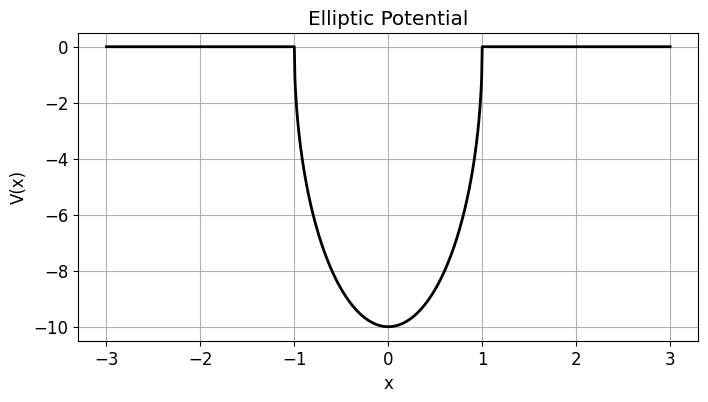

In [ ]:
# ── Q4: Elliptic Potential Bound States ──────────────────────────────────
# Natural units: hbar=1, 2m=1, a=1, V0=10
import numpy as np
import matplotlib.pyplot as plt

V0_q4 = 10.0
a_q4  = 1.0

def pot_elliptic(x):
    x = np.asarray(x)
    V = np.zeros_like(x, dtype=float)
    mask = np.abs(x) <= a_q4
    V[mask] = -V0_q4 * np.sqrt(a_q4**2 - x[mask]**2)
    return V

# Plot potential
xs_p = np.linspace(-3, 3, 1000)
plt.figure(figsize=(8,4))
plt.plot(xs_p, pot_elliptic(xs_p), 'k-', lw=2)
plt.xlabel('x'); plt.ylabel('V(x)'); plt.title('Elliptic Potential'); plt.grid(); plt.show()

# TISE: psi'' = (V(x) - E)*psi  [natural units hbar=1, 2m=1]
def ode_schro(x, psi, E):
    return np.array([psi[1], (pot_elliptic(x) - E)*psi[0]])

# Shooting with log-derivative matching at xm = 0.5
xm     = 0.5
N_q4   = 3001
x_left  = np.linspace(-3.0, xm, N_q4)
x_right = np.linspace(3.0,  xm, N_q4)
h_q4   = x_left[1] - x_left[0]

def mismatch(E):
    kappa = np.sqrt(-E)   # E<0
    # Left integration from x=-3
    psi_L = np.array([np.exp(-3*kappa), kappa*np.exp(-3*kappa)])
    for x in x_left[:-1]:
        psi_L = rk4_k(ode_schro, x, psi_L, E, abs(h_q4))
    logder_L = psi_L[1] / psi_L[0]
    # Right integration from x=+3
    psi_R = np.array([np.exp(-3*kappa), -kappa*np.exp(-3*kappa)])
    h_r   = x_right[1] - x_right[0]   # negative (going left)
    for x in x_right[:-1]:
        psi_R = rk4_k(ode_schro, x, psi_R, E, abs(h_r))
    logder_R = psi_R[1] / psi_R[0]
    return logder_L - logder_R   # F(E)

# Scan and find zeros
E_scan  = np.linspace(-V0_q4+0.1, -0.01, 2000)
F_scan  = np.array([mismatch(e) for e in E_scan])

# Plot mismatch
plt.figure(figsize=(9,4))
plt.plot(E_scan, F_scan); plt.axhline(0,color='k',lw=0.8)
plt.ylim(-50,50); plt.xlabel('E'); plt.ylabel('F(E)'); plt.title('Mismatch function'); plt.grid(); plt.show()

# Find eigenvalues
eigenvalues_q4 = []
for i in range(len(E_scan)-1):
    if F_scan[i]*F_scan[i+1] < 0 and abs(F_scan[i])<40 and abs(F_scan[i+1])<40:
        try:
            ev, _ = bisection(mismatch, E_scan[i], E_scan[i+1], eps=1e-6)
            eigenvalues_q4.append(ev)
        except:
            pass

print(f"Found {len(eigenvalues_q4)} bound states:")
for n, ev in enumerate(eigenvalues_q4):
    print(f"  E_{n} = {ev:.6f}  (|F|={abs(mismatch(ev)):.2e})")


In [ ]:
# ── Q4: Reconstruct and plot eigenfunctions ──────────────────────────────
fig, ax = plt.subplots(figsize=(9,6))
xs_full = np.linspace(-3, 3, 1000)
ax.plot(xs_full, pot_elliptic(xs_full), 'k-', lw=2, label='V(x)')

colors_q4 = ['blue','red','green','purple','orange']
for n, ev in enumerate(eigenvalues_q4[:5]):
    kappa = np.sqrt(-ev)
    # Left
    psi_L = np.array([np.exp(-3*kappa), kappa*np.exp(-3*kappa)])
    xl = np.linspace(-3.0, xm, N_q4)
    hl = xl[1]-xl[0]
    psi_L_arr = [psi_L[0]]
    for x in xl[:-1]:
        psi_L = rk4_k(ode_schro, x, psi_L, ev, hl)
        psi_L_arr.append(psi_L[0])
    # Right
    psi_R = np.array([np.exp(-3*kappa), -kappa*np.exp(-3*kappa)])
    xr = np.linspace(3.0, xm, N_q4)
    hr = xr[1]-xr[0]
    psi_R_arr = [psi_R[0]]
    for x in xr[:-1]:
        psi_R = rk4_k(ode_schro, x, psi_R, ev, hr)
        psi_R_arr.append(psi_R[0])
    # Scale and join
    scale = psi_L_arr[-1] / psi_R_arr[-1]
    psi_full_x = np.concatenate([xl, xr[::-1]])
    psi_full_y = np.concatenate([psi_L_arr, (scale*np.array(psi_R_arr[::-1]))])
    # Normalize
    h_norm = psi_full_x[1]-psi_full_x[0]
    norm = np.sqrt(np.abs(trapezoid(psi_full_y**2, h_norm)))
    psi_norm_q4 = psi_full_y / norm
    ax.plot(psi_full_x, ev + psi_norm_q4*2, colors_q4[n], label=f'ψ_{n}, E={ev:.3f}')
    ax.axhline(ev, color=colors_q4[n], ls='--', alpha=0.4)

ax.set_xlabel('x'); ax.set_ylabel('E + ψ(x)'); ax.set_title('Elliptic Well Eigenfunctions')
ax.legend(fontsize=9); ax.grid(); plt.show()


---
# 📄 Paper 4: CT2 (`ct2-v4.pdf`)
---


## Q1 — Cubic Anharmonic Oscillator [25 marks]

### (a) Dimensionless derivation

Set $\xi = x/|x_0|$ where $x_0 = -m\omega^2/(3\lambda)$, $\tau=\omega t$:

$$\xi'' = -\xi + \xi^2$$

Dimensionless potential: $\mathcal{V}(\xi) = \tfrac{1}{2}\xi^2 - \tfrac{1}{3}\xi^3$. Barrier at $\xi=1$, $\mathcal{V}(1)=1/6$.

### (b) Period of small oscillations

$\omega_{\rm eff} = 1 - 5A^2/12$. For $A=0.3$: $\omega_{\rm eff} = 1 - 5(0.09)/12 = 1 - 0.0375 = 0.9625$

The cubic term makes the potential shallower on one side, reducing the restoring force and thus lowering the frequency.


In [ ]:
# ── Q1: Cubic Anharmonic Oscillator ──────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

def V_anh(xi):
    return 0.5*xi**2 - xi**3/3

def E_anh(xi, xi_dot):
    return 0.5*xi_dot**2 + V_anh(xi)

def odes_anh(tau, state):
    xi, xi_dot = state
    return np.array([xi_dot, -xi + xi**2])

# Analytic omega_eff for small A
A_test = 0.3
omega_eff = 1 - 5*A_test**2/12
print(f"(b) omega_eff for A=0.3: {omega_eff:.6f}")

h_anh = 1e-2

# Case A: xi(0)=0.3, xi'(0)=0, tau to 50
ts_A = np.arange(0, 50, h_anh)
solA = caller_rk4(odes_anh, [0.3, 0.0], ts_A, h_anh)
EA   = E_anh(solA[:,0], solA[:,1])
print(f"Case A energy drift: {np.max(np.abs(EA - EA[0])):.2e}  (should be < 1e-4)")

# Case B: xi(0)=0.9, xi'(0)=0, tau to 50
ts_B = np.arange(0, 50, h_anh)
solB = caller_rk4(odes_anh, [0.9, 0.0], ts_B, h_anh)
EB   = E_anh(solB[:,0], solB[:,1])
print(f"Case B energy drift: {np.max(np.abs(EB - EB[0])):.2e}  (should be < 1e-4)")

# Case C: xi(0)=0.3, xi'(0)=0.6, run until xi>5 or tau=100
h_C = 1e-3
ts_C_arr, solC_arr = [], []
state_C = np.array([0.3, 0.6])
tau_C = 0.0
while state_C[0] <= 5 and tau_C < 100:
    ts_C_arr.append(tau_C)
    solC_arr.append(state_C.copy())
    state_C = rk4(odes_anh, tau_C, state_C, h_C)
    tau_C += h_C
ts_C   = np.array(ts_C_arr)
solC   = np.array(solC_arr)

# Find escape time (xi crosses 1)
xi_C = solC[:,0]
for i in range(len(xi_C)-1):
    if xi_C[i] < 1 <= xi_C[i+1]:
        t_escape = ts_C[i]
        break
print(f"Case C escape (ξ=1) at τ ≈ {t_escape:.4f}")

# Phase portrait
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(solA[:,0], solA[:,1], label='A: (0.3,0)'); axes[0].plot(solB[:,0], solB[:,1], label='B: (0.9,0)')
axes[0].plot(solC[:,0], solC[:,1], label='C: (0.3,0.6)', alpha=0.6)
axes[0].axvline(1, color='k', ls='--', label='barrier ξ=1'); axes[0].set_xlabel('ξ'); axes[0].set_ylabel("ξ'")
axes[0].set_title('Phase Portrait'); axes[0].legend(fontsize=9); axes[0].grid()

axes[1].plot(ts_A, EA - EA[0], label='Case A'); axes[1].plot(ts_B, EB - EB[0], label='Case B')
axes[1].axhline(1e-4, color='k', ls='--'); axes[1].axhline(-1e-4, color='k', ls='--')
axes[1].set_xlabel('τ'); axes[1].set_ylabel('E(τ)-E(0)'); axes[1].set_title('Energy drift'); axes[1].legend(); axes[1].grid()
plt.tight_layout(); plt.show()

# Case C time series with escape marked
fig2, ax2 = plt.subplots(figsize=(9,4))
ax2.plot(ts_C, xi_C); ax2.axhline(1, color='r', ls='--', label='ξ=1')
ax2.axvline(t_escape, color='g', ls=':', label=f'escape τ={t_escape:.3f}')
ax2.set_xlabel('τ'); ax2.set_ylabel('ξ'); ax2.set_title('Case C: Escape'); ax2.legend(); ax2.grid(); plt.show()


## Q2 — Flat-Bottomed Well with Drag [25 marks]

### (b) Trapping analysis

Without drag: period $T_0 = (4+2\pi)/\omega$.

The particle enters at $\xi=1$ with speed $\xi'=1$. Since $1^2 = 1 < 2\pi \approx 6.28$, it is immediately trapped in the right wall.

Inside the right wall: damped SHM about $\xi=1$. By energy balance:
$\frac{1}{2}(\xi')^2_{\rm enter} = \frac{1}{2}\Delta\xi^2 + \text{drag work}$

For entrance speed $v_{\rm in}=1$ with damping force = 1 (dimensionless):
$\frac{1}{2}(1)^2 = \frac{1}{2}\Delta\xi^2 + 1\cdot\Delta\xi \Rightarrow \Delta\xi^2 + 2\Delta\xi - 1 = 0 \Rightarrow \Delta\xi = -1+\sqrt{2} \approx 0.414$

So $\xi^* = 1 + (-1+\sqrt{2}) \approx 1.414$


In [ ]:
# ── Q2: Flat-Bottomed Well with Drag ─────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

# Analytical trapping position
Delta_xi = -1 + np.sqrt(2)
xi_star_analytic = 1 + Delta_xi
print(f"Analytic trapping position: ξ* = 1 + (-1+√2) = {xi_star_analytic:.6f}")
T0_nodrag = (4 + 2*np.pi)   # dimensionless (omega=1)
print(f"Undamped period T0 = (4+2π)/ω = {T0_nodrag:.6f} (ω=1 units)")

def sgn(x):
    if x > 0: return 1
    elif x < 0: return -1
    else: return 0

def odes_flat(tau, state, s):
    xi, xi_dot = state
    if xi <= -1:
        return np.array([xi_dot, -(xi+1) - s])
    elif abs(xi) < 1:
        return np.array([xi_dot, -s])
    else:  # xi >= 1
        return np.array([xi_dot, -(xi-1) - s])

# RK4 with sign held constant per step
def rk4_flat(tau, state, h):
    s = sgn(state[1])
    k1 = h * odes_flat(tau,       state,           s)
    k2 = h * odes_flat(tau+h/2,   state + k1/2,    s)
    k3 = h * odes_flat(tau+h/2,   state + k2/2,    s)
    k4 = h * odes_flat(tau+h,     state + k3,      s)
    return state + (k1+2*k2+2*k3+k4)/6

h_flat = 5e-3
state_flat = np.array([0.0, 3.0])
tau_flat = 0.0
taus_flat, xis_flat, xdots_flat = [0.0], [0.0], [3.0]
stopped_time = None

while True:
    state_flat = rk4_flat(tau_flat, state_flat, h_flat)
    tau_flat  += h_flat
    taus_flat.append(tau_flat)
    xis_flat.append(state_flat[0])
    xdots_flat.append(state_flat[1])
    # Check: |xi'| < 1e-3 for one time unit
    if abs(state_flat[1]) < 1e-3:
        if stopped_time is None:
            stopped_time = tau_flat
        elif tau_flat - stopped_time > 1.0:
            break
    else:
        stopped_time = None
    if tau_flat > 50:
        break

taus_flat   = np.array(taus_flat)
xis_flat    = np.array(xis_flat)
xdots_flat  = np.array(xdots_flat)

xi_rest_num = xis_flat[-1]
print(f"Numerical  resting position: ξ* = {xi_rest_num:.6f}")
print(f"Analytical resting position: ξ* = {xi_star_analytic:.6f}")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(taus_flat, xis_flat); axes[0].axhline(1, color='r', ls='--', alpha=0.5)
axes[0].axhline(-1, color='r', ls='--', alpha=0.5); axes[0].set_xlabel('τ'); axes[0].set_ylabel('ξ')
axes[0].set_title('Time series (with drag)'); axes[0].grid()

axes[1].plot(xis_flat, xdots_flat, 'b-', lw=0.8); 
axes[1].plot(xi_rest_num, 0, 'ro', ms=8, label=f'ξ*={xi_rest_num:.3f}')
axes[1].set_xlabel('ξ'); axes[1].set_ylabel("ξ'"); axes[1].set_title('Phase portrait'); axes[1].legend(); axes[1].grid()
plt.tight_layout(); plt.show()

# Without drag to verify period
def odes_nodrag(tau, state):
    xi, xi_dot = state
    if xi <= -1: return np.array([xi_dot, -(xi+1)])
    elif abs(xi) < 1: return np.array([xi_dot, 0.0])
    else: return np.array([xi_dot, -(xi-1)])

ts_nd = np.arange(0, T0_nodrag*2, h_flat)
sol_nd = caller_rk4(odes_nodrag, [0.0, 3.0], ts_nd, h_flat)
# Find period by finding first return to xi=0 going negative
xi_nd = sol_nd[:,0]
period_found = None
for i in range(10, len(xi_nd)-1):
    if xi_nd[i]*xi_nd[i+1] < 0 and sol_nd[i,1] < 0:
        period_found = 2*ts_nd[i]
        break
if period_found:
    print(f"Numerical period (no drag) = {period_found:.4f}, T0 = {T0_nodrag:.4f}, err = {abs(period_found-T0_nodrag)/T0_nodrag*100:.2f}%")


## Q3 — Half-Harmonic Trap with Hard Wall [25 marks]

### (b) Quantum bound states

Schrödinger equation inside well ($0 \le x \le x_b$):
$\psi'' = \frac{2m}{\hbar^2}(\frac{1}{2}m\omega^2 x^2 - V_0 - E)\psi$

with $\alpha = V_0/(\hbar\omega) = 5$ and matching condition $\psi'(x_b)/\psi(x_b) = -\kappa$.


In [ ]:
# ── Q3: Half-Harmonic Trap Bound States ──────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

alpha_hh = 5.0    # V0/(hbar*omega)
# Work in units hbar=1, m=1, omega=1 => xb = sqrt(2*V0) = sqrt(2*alpha)
xb = np.sqrt(2*alpha_hh)   # = sqrt(10)
V0_hh = alpha_hh           # in units of hbar*omega

def pot_hh(x):
    """Potential in units of hbar*omega: 0.5*x^2 - V0 for x in [0,xb], 0 otherwise."""
    if x < 0: return np.inf
    elif x <= xb: return 0.5*x**2 - V0_hh
    else: return 0.0

def ode_hh(x, psi, E):
    """psi'' = (V - E)*psi in units with hbar=1, m=1."""
    V = 0.5*x**2 - V0_hh if 0 <= x <= xb else 0.0
    return np.array([psi[1], (V - E)*psi[0]])

N_hh = 1000
x_arr_hh = np.linspace(0, xb, N_hh)
h_hh = x_arr_hh[1] - x_arr_hh[0]

def shoot_match_hh(E):
    """Integrate from x=0 (psi=0, psi'=1), return mismatch of log-derivative at xb."""
    if E >= 0: return 1e10
    kappa = np.sqrt(-E)
    # BC at right: kappa * psi(xb) + psi'(xb) = 0  =>  log-der = -kappa
    psi = np.array([0.0, 1.0])   # psi(0)=0, psi'(0)=1
    for x in x_arr_hh[:-1]:
        psi = rk4_k(ode_hh, x, psi, E, h_hh)
    log_der_num = psi[1] / psi[0] if abs(psi[0]) > 1e-20 else 1e10
    return log_der_num + kappa

# Scan
E_scan_hh = np.linspace(-V0_hh+0.01, -0.01, 3000)
F_scan_hh = np.array([shoot_match_hh(e) for e in E_scan_hh])

# Find eigenvalues
eigs_hh = []
for i in range(len(E_scan_hh)-1):
    if F_scan_hh[i]*F_scan_hh[i+1] < 0 and abs(F_scan_hh[i])<50:
        try:
            ev, _ = bisection(shoot_match_hh, E_scan_hh[i], E_scan_hh[i+1], eps=1e-8)
            eigs_hh.append(ev)
        except:
            pass

print("Bound states (in units of hbar*omega):")
for n, ev in enumerate(eigs_hh):
    print(f"  E_{n} = {ev:.6f} hbar*omega")

# Comparison with pure HO (odd states: E_n^HO = (4n+3)/2 - V0)
print("\nComparison with half-harmonic oscillator (HO odd states):")
print("n   E_n (num)   E_n^HO = (4n+3)/2 - V0")
for n, ev in enumerate(eigs_hh[:4]):
    E_HO = (4*n + 3)/2 - V0_hh
    print(f"{n}   {ev:.4f}      {E_HO:.4f}")
print("True energies are lower than HO because flat region beyond xb allows spreading -> lower KE.")


## Q4 — Finite Parabolic Well + WKB [25 marks]

### (b) Action integral — analytic result

$$S(E) = \int_{-\sqrt{1+E}}^{\sqrt{1+E}}\sqrt{(1+E)-\xi^2}\,d\xi = \frac{\pi}{2}(1+E)$$

(by substitution $\xi = \sqrt{1+E}\sin\theta$, integral becomes $\frac{\pi}{2}(1+E)$)

### (c) WKB eigenvalues

$\Lambda\cdot S(E_n) = (n+1/2)\pi \Rightarrow \frac{\pi\Lambda}{2}(1+E_n) = (n+1/2)\pi$

$$E_n = \frac{2n+1}{\Lambda} - 1$$


In [ ]:
# ── Q4: Finite Parabolic Well — WKB ───────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

Lambda = 6.0

# Exact S(E)
def S_exact(E):
    return (np.pi/2)*(1 + E)

# Numerical S(E) using Simpson
def Pi_mom(xi, E):
    val = E - (xi**2 - 1)   # E - V(xi), V(xi) = xi^2-1
    return np.sqrt(np.maximum(val, 0.0))

def S_numeric(E, N=200):
    xi_p = np.sqrt(1 + E)
    return simpson(lambda xi: Pi_mom(xi, E), -xi_p, xi_p, N)

# Verify numerics
print("Numerical vs exact S(E):")
for E_test in [-0.8, -0.5, -0.2]:
    Sn = S_numeric(E_test)
    Se = S_exact(E_test)
    print(f"  E={E_test}: S_numeric={Sn:.6f}, S_exact={Se:.6f}, err={abs(Sn-Se):.2e}")

# WKB eigenvalues: E_n = (2n+1)/Lambda - 1
print(f"\nWKB eigenvalues for Λ={Lambda}:")
print("n    E_n           in (-1, 0)?")
n_wkb = 0
eigs_wkb = []
while True:
    En = (2*n_wkb + 1)/Lambda - 1
    if En >= 0:
        break
    eigs_wkb.append(En)
    print(f"{n_wkb}    {En:.6f}      {-1 < En < 0}")
    n_wkb += 1

# Plots
xi_plot = np.linspace(-1.2, 1.2, 500)
V_plot  = np.where(np.abs(xi_plot)<=1, xi_plot**2-1, 0.0)

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(xi_plot, V_plot, 'k-', lw=2, label='V(ξ)')
colors_wkb = plt.cm.viridis(np.linspace(0,0.8,len(eigs_wkb)))
for n, En in enumerate(eigs_wkb):
    xi_p = np.sqrt(1+En)
    axes[0].axhline(En, color=colors_wkb[n], ls='--', label=f'E_{n}={En:.3f}')
    axes[0].plot([-xi_p, xi_p], [En, En], 'o', color=colors_wkb[n], ms=6)
axes[0].set_xlabel('ξ'); axes[0].set_ylabel('E'); axes[0].set_title('WKB levels + turning points'); axes[0].legend(fontsize=9); axes[0].grid()

E_range_wkb = np.linspace(-0.99, -0.01, 200)
axes[1].plot(E_range_wkb, S_exact(E_range_wkb), 'b-', lw=2, label='S(E) exact')
for n, En in enumerate(eigs_wkb):
    axes[1].axhline((n+0.5)*np.pi/Lambda, color=colors_wkb[n], ls='--', alpha=0.8, label=f'(n+½)π/Λ, n={n}')
axes[1].set_xlabel('E'); axes[1].set_ylabel('S(E)'); axes[1].set_title('Action vs Energy'); axes[1].legend(fontsize=9); axes[1].grid()
plt.tight_layout(); plt.show()


---
# 📄 Paper 5: Class Test 1 (`classtest-1.pdf`)
---


## Q1 — Planck Integral using Simpson's 3/8 rule [10 marks]

$$\int_0^\infty \frac{x^3}{e^x-1}dx = \frac{\pi^4}{15} \approx 6.493939$$


In [ ]:
# ── Q1: Planck Integral ───────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

exact_val = np.pi**4 / 15
print(f"Exact value π⁴/15 = {exact_val:.8f}")

def f_planck(x):
    # handle x=0 singularity
    x = np.asarray(x, dtype=float)
    result = np.zeros_like(x)
    mask = x > 1e-10
    result[mask] = x[mask]**3 / (np.exp(x[mask]) - 1)
    return result

def boole(f, a, b, m):
    """Boole's rule (quartic): N=4m+1 points."""
    N = 4*m + 1
    x = np.linspace(a, b, N)
    h = x[1]-x[0]
    fx = f(x)
    total = 7*(fx[0]+fx[-1])
    for i in range(1, N-1):
        if (i % 4) == 0: total += 14*fx[i]
        elif (i % 2) == 0: total += 12*fx[i]
        else: total += 32*fx[i]
    return 2*h/45 * total

def simpson_38(f, a, b, m):
    """Simpson's 3/8 rule: N=3m+1 points."""
    N = 3*m + 1
    x = np.linspace(a, b, N)
    h = x[1]-x[0]
    fx = f(x)
    total = fx[0]+fx[-1]
    for i in range(1, N-1):
        if i % 3 == 0: total += 2*fx[i]
        else: total += 3*fx[i]
    return 3*h/8 * total

xmax = 12.0   # integrand negligible beyond ~10

for m in [4, 8, 16, 32, 64]:
    I_38   = simpson_38(f_planck, 1e-10, xmax, m)
    I_boole = boole(f_planck, 1e-10, xmax, m)
    I_simp  = simpson(f_planck, 1e-10, xmax, 4*m+1)
    print(f"m={m:3d}  Simpson38={I_38:.8f} (err={abs(I_38-exact_val):.2e})  Boole={I_boole:.8f} (err={abs(I_boole-exact_val):.2e})")


## Q2 — LJ Potential Minimum (Root Finding) [10 marks]

Force: $F(r) = -dV/dr = 4\varepsilon[12\sigma^{12}/r^{13} - 6\sigma^6/r^7]$

Root at $r^* = 2^{1/6}\sigma \approx 1.12246$


In [ ]:
# ── Q2: LJ Potential Root Finding ─────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

eps_lj = 1.0
sig_lj = 1.0

def F_lj(r):
    """Force = -dV/dr for LJ potential."""
    return 4*eps_lj * (12*sig_lj**12/r**13 - 6*sig_lj**6/r**7)

def dF_lj(r):
    return 4*eps_lj * (-156*sig_lj**12/r**14 + 42*sig_lj**6/r**8)

r_exact = 2**(1/6) * sig_lj
print(f"Exact r* = 2^(1/6) = {r_exact:.8f}")

# Plot F(r)
r_plot = np.linspace(0.8, 3, 400)
plt.figure(figsize=(8,4))
plt.plot(r_plot, F_lj(r_plot)); plt.axhline(0, color='k', lw=0.8)
plt.ylim(-20, 20); plt.xlabel('r'); plt.ylabel('F(r)'); plt.title('LJ Force'); plt.grid(); plt.show()

# Bisection
r_root_bis, it_bis = bisection(F_lj, 1.0, 1.4, eps=1e-8)
print(f"Bisection:   r* = {r_root_bis:.8f}  (iter={it_bis})")

# Newton
r_root_nr, it_nr = newton(F_lj, dF_lj, 1.0, eps=1e-8)
print(f"Newton-R:    r* = {r_root_nr:.8f}  (iter={it_nr})")

# Secant
r_root_sec, it_sec = secant(F_lj, 1.0, 1.1, eps=1e-8)
print(f"Secant:      r* = {r_root_sec:.8f}  (iter={it_sec})")


## Q3 — Planetary Orbit via Velocity Verlet [10 marks]


In [ ]:
# ── Q3: Planetary Orbit — Velocity Verlet ─────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

# Units: GM=1, so circular orbit at r=1 has v=1
GM = 1.0

def accel(x, y):
    r = np.sqrt(x**2 + y**2)
    return -GM*x/r**3, -GM*y/r**3

# Initial conditions: circular orbit r=1
x, y   = 1.0, 0.0
vx, vy = 0.0, 1.0    # circular speed = sqrt(GM/r) = 1
dt     = 0.01
T_orb  = 2*np.pi     # orbital period
N_orbs = 10
N_steps = int(N_orbs * T_orb / dt)

xs_orb, ys_orb, Es_orb, ts_orb = [x], [y], [], [0.0]
ax0, ay0 = accel(x, y)

for i in range(N_steps):
    # Velocity Verlet
    x  += vx*dt + 0.5*ax0*dt**2
    y  += vy*dt + 0.5*ay0*dt**2
    ax1, ay1 = accel(x, y)
    vx += 0.5*(ax0+ax1)*dt
    vy += 0.5*(ay0+ay1)*dt
    ax0, ay0 = ax1, ay1
    xs_orb.append(x); ys_orb.append(y); ts_orb.append((i+1)*dt)

xs_orb = np.array(xs_orb); ys_orb = np.array(ys_orb); ts_orb = np.array(ts_orb)
rs_orb = np.sqrt(xs_orb**2 + ys_orb**2)
vs_orb = np.sqrt(vx**2 + vy**2)   # final speed (approx)

# Energy: E = 0.5*v^2 - GM/r  (need to track fully)
# Recompute properly
x, y = 1.0, 0.0; vx, vy = 0.0, 1.0; ax0, ay0 = accel(x,y)
E_track = []
for i in range(N_steps):
    E_track.append(0.5*(vx**2+vy**2) - GM/np.sqrt(x**2+y**2))
    x  += vx*dt + 0.5*ax0*dt**2; y  += vy*dt + 0.5*ay0*dt**2
    ax1, ay1 = accel(x, y); vx += 0.5*(ax0+ax1)*dt; vy += 0.5*(ay0+ay1)*dt; ax0, ay0 = ax1, ay1
E_track = np.array(E_track)

print(f"Initial energy: {E_track[0]:.6f}")
print(f"Energy drift over {N_orbs} orbits: {np.max(np.abs(E_track-E_track[0])):.2e}")

fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].plot(xs_orb, ys_orb, 'b-', lw=0.5); axes[0].plot(0,0,'k*',ms=10,label='Star')
axes[0].set_aspect('equal'); axes[0].set_title('Orbit (Velocity Verlet)'); axes[0].legend(); axes[0].grid()
axes[1].plot(ts_orb[:-1], E_track-E_track[0])
axes[1].set_xlabel('t'); axes[1].set_ylabel('ΔE'); axes[1].set_title('Energy conservation'); axes[1].grid()
plt.tight_layout(); plt.show()


## Q4 — Projectile with Quadratic Drag [10 marks]


In [ ]:
# ── Q4: Projectile with Quadratic Drag ───────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

m_proj = 1.0; g_proj = 9.81; v0_proj = 50.0; theta0 = 45*np.pi/180; Cd = 0.1

def odes_proj(t, state):
    x, y, vx, vy = state
    speed = np.sqrt(vx**2 + vy**2)
    ax = -Cd/m_proj * speed * vx
    ay = -g_proj - Cd/m_proj * speed * vy
    return np.array([vx, vy, ax, ay])

# Initial conditions
vx0 = v0_proj*np.cos(theta0); vy0 = v0_proj*np.sin(theta0)
state = np.array([0.0, 0.0, vx0, vy0])
h_p  = 0.01

trajectory = [state.copy()]
t_p = 0.0

while state[1] >= 0 or t_p < 0.1:
    state_new = rk4(odes_proj, t_p, state, h_p)
    if state[1] >= 0 and state_new[1] < 0:
        # Refine landing
        t_land, _ = bisection(lambda t: np.interp(t, [t_p, t_p+h_p], [state[1], state_new[1]]), t_p, t_p+h_p, eps=1e-6)
        state = rk4(odes_proj, t_p, state, t_land - t_p)
        trajectory.append(state.copy())
        break
    state = state_new
    t_p  += h_p
    trajectory.append(state.copy())

traj = np.array(trajectory)
print(f"Range (with drag): {traj[-1,0]:.2f} m")

# Without drag (analytical)
T_flight = 2*vy0/g_proj
R_nodrag = v0_proj**2*np.sin(2*theta0)/g_proj
print(f"Range (no drag):   {R_nodrag:.2f} m")

plt.figure(figsize=(9,4))
plt.plot(traj[:,0], traj[:,1], 'b-', label=f'With drag (Cd={Cd})')
t_nd = np.linspace(0, T_flight, 200)
plt.plot(v0_proj*np.cos(theta0)*t_nd, vy0*t_nd - 0.5*g_proj*t_nd**2, 'r--', label='No drag')
plt.xlabel('x [m]'); plt.ylabel('y [m]'); plt.title('Projectile Motion'); plt.legend(); plt.grid(); plt.show()


---
## 🔑 Quick Reference: Common Patterns

| Task | Function to use |
|------|-----------------|
| Integrate ODE (no param) | `caller_rk4(f, y_ini, ts, h)` |
| Integrate ODE (with param E) | `caller_rk4_k(f, xlim, yini, E, N)` |
| Root finding | `bisection(f, L, R)` or `newton(f, fp, x0)` or `secant(f, x1, x2)` |
| Numerical integral | `simpson(f, a, b, N)` or `trapezoid(f_arr, h)` |
| Eigenvalue from shooting | scan for sign changes in mismatch function, then bisection |
| Log-derivative matching | `F(E) = psi_L'/psi_L - psi_R'/psi_R` at xm |
